In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import pulp
from pulp import *
import matplotlib.pyplot as plt

In [4]:
#creates all the edges with the milage between each node
edges = [
# Miami
("Miami","West Palm Beach",70),
("Miami","Port St. Lucie",113),
("Miami","Orlando",251),
("Miami","Lehigh Acres",138),
("Miami","Cape Coral",159),
("Miami","Lakeland",230),
("Miami","Tampa",282),

# West Palm
("West Palm Beach","Port St. Lucie",48),
("West Palm Beach","Orlando",170),
("West Palm Beach","Lehigh Acres",115),
("West Palm Beach","Lakeland",170),
("West Palm Beach","Tampa",206),

# Port St Lucie
("Port St. Lucie","Orlando",125),
("Port St. Lucie","Lehigh Acres",123),
("Port St. Lucie","Palm Bay",62),
("Port St. Lucie","Lakeland",127),
("Port St. Lucie","Tampa",195),

# Orlando
("Orlando","Lakeland",55),
("Orlando","Tampa",125),
("Orlando","Jacksonville",140),
("Orlando","Gainesville",114),

# Lehigh
("Lehigh Acres","Cape Coral",25),
("Lehigh Acres","Palm Bay",192),
("Lehigh Acres","Lakeland",118),
("Lehigh Acres","Tampa",140),

# Cape Coral
("Cape Coral","Palm Bay",180),
("Cape Coral","Lakeland",118),
("Cape Coral","Tampa",132),

# Palm Bay
("Palm Bay","Orlando",75),
("Palm Bay","Lakeland",106),
("Palm Bay","Jacksonville",179),
("Palm Bay","Gainesville",187),

# Lakeland
("Lakeland","Tampa",35),
("Lakeland","Gainesville",124),

# Tampa
("Tampa","Gainesville",132),

# Jacksonville
("Jacksonville","Gainesville",72)
]

G = nx.Graph()

for u,v,w in edges:
    G.add_edge(u,v,weight=w)

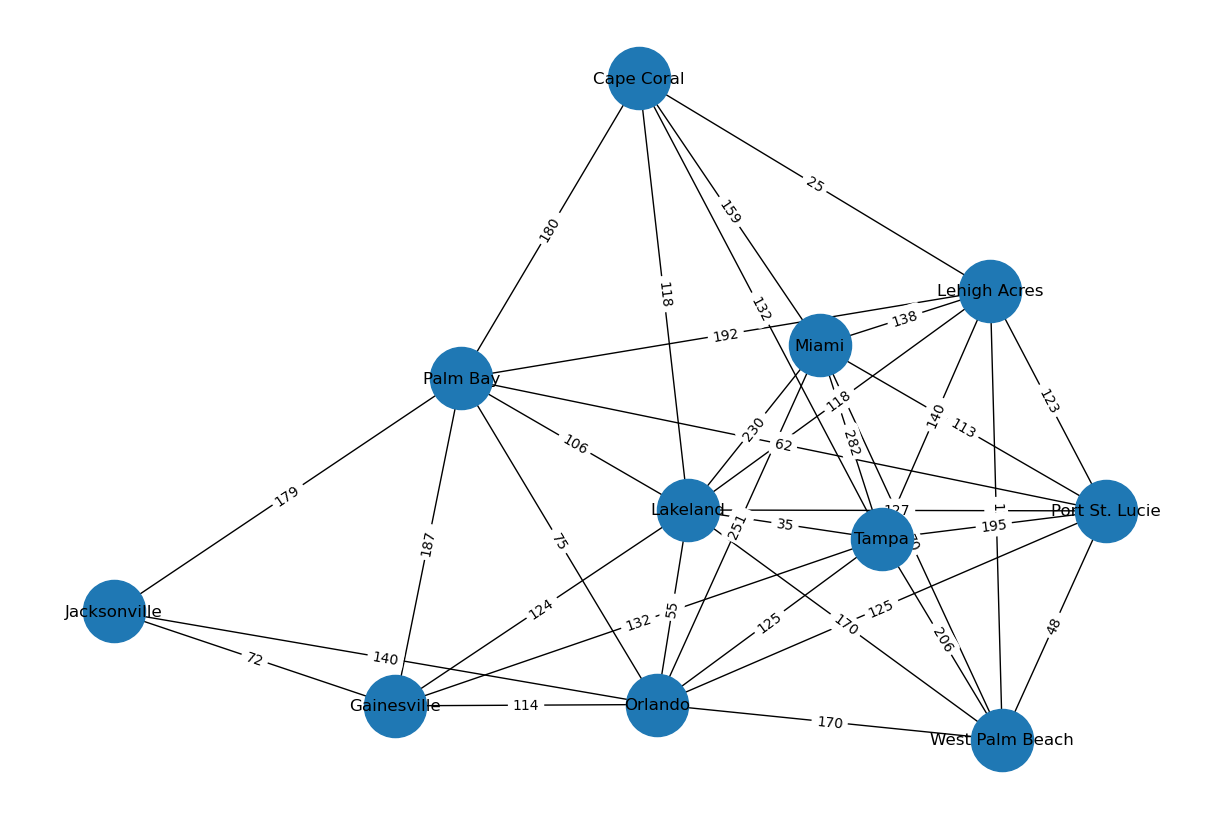

In [5]:
#visual representation of the network
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000)
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

plt.show()

In [6]:
#evacuation city populations
pop = {"Miami": 500000,
       "West Palm Beach": 118000,
       "Port St. Lucie": 205000,
       "Lehigh Acres": 114000,
       "Cape Coral": 194000,
       "Palm Bay": 120000}

#shelter capacities (estimated from city population
capacity = {"Orlando": 305000,
            "Lakeland": 110000,
            "Tampa": 385000,
            "Jacksonville": 950000,
            "Gainesville": 140000}

In [7]:
#minimizatiion optimization problem
model = LpProblem("Hurricane_Evacuation", LpMinimize)

#creates a list using the milage nodes
directed_edges = []
for u,v,w in edges:
    directed_edges.append((u,v,w))
    directed_edges.append((v,u,w))

#linear programming variable for the flow on each edge
flow = LpVariable.dicts("flow", 
                        [(u,v) for u,v,w in directed_edges],
                        lowBound=0)

#objective: minimize total milage
model += lpSum(w * flow[(u,v)] for u,v,w in directed_edges)

#creates a list of all the cities
nodes = list(G.nodes())

#for each node (city) gets the inflow (people arriving) and outflow (people leaving_
for node in nodes:
    inflow = lpSum(flow[(u,v)] for u,v,w in directed_edges if v == node)
    outflow = lpSum(flow[(u,v)] for u,v,w in directed_edges if u == node)

    #evacuation origins
    if node in pop:
        model += outflow - inflow == pop[node]
    #shelters
    elif node in capacity:
        model += inflow - outflow <= capacity[node]
    #transfer nodes
    else:
        model += outflow - inflow == 0

#solves the model and prints if the problem is solvable
model.solve()
print("Status:", LpStatus[model.status])

Status: Optimal


In [8]:
#prints the total milage
print("Total Miles:",
      value(model.objective))

Total Miles: 267048000.0


In [9]:
#finds the distance for each edge
distance_lookup = {}
for u, v, d in edges:
    distance_lookup[(u, v)] = d
    distance_lookup[(v, u)] = d

#for each road gets the number of people driving on it and gets the milage from those people
total_distance_miles = 0
for (u, v, d) in directed_edges:
    f = flow[(u, v)].varValue
    if f is None or f <= 0:
        continue

    #get distance for this edge
    dist = distance_lookup[(u, v)]

    #compute distance-miles
    dm = f * dist
    total_distance_miles += dm

    print(f"('{u}', '{v}') flow: {f:.0f} distance: {dist} distance-miles: {dm:.2f}")

print("Total distance-miles:", total_distance_miles)

('Miami', 'Port St. Lucie') flow: 313000 distance: 113 distance-miles: 35369000.00
('Miami', 'Lakeland') flow: 187000 distance: 230 distance-miles: 43010000.00
('West Palm Beach', 'Orlando') flow: 118000 distance: 170 distance-miles: 20060000.00
('Port St. Lucie', 'Orlando') flow: 327000 distance: 125 distance-miles: 40875000.00
('Port St. Lucie', 'Palm Bay') flow: 191000 distance: 62 distance-miles: 11842000.00
('Orlando', 'Gainesville') flow: 140000 distance: 114 distance-miles: 15960000.00
('Lehigh Acres', 'Tampa') flow: 114000 distance: 140 distance-miles: 15960000.00
('Cape Coral', 'Tampa') flow: 194000 distance: 132 distance-miles: 25608000.00
('Palm Bay', 'Jacksonville') flow: 311000 distance: 179 distance-miles: 55669000.00
('Lakeland', 'Tampa') flow: 77000 distance: 35 distance-miles: 2695000.00
Total distance-miles: 267048000.0


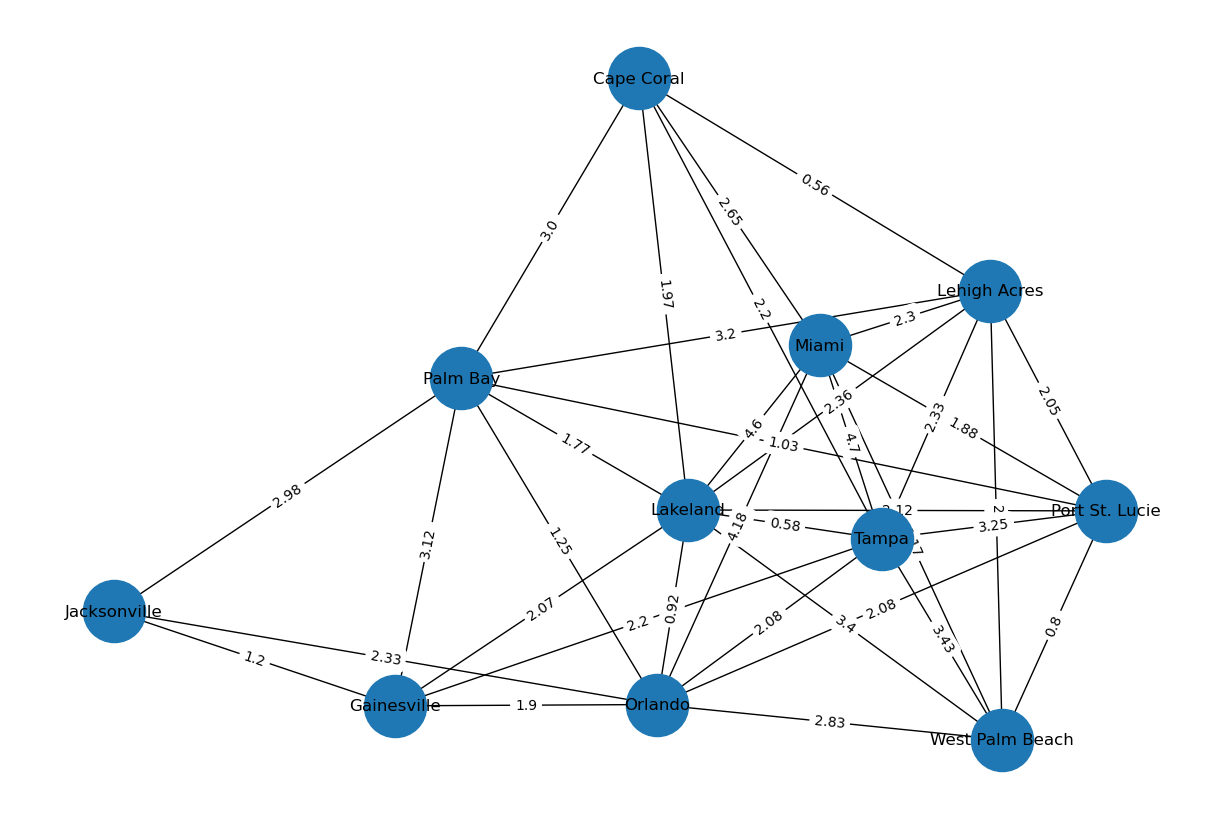

In [10]:
#creates edges using the milage from before divided by the average speed limit on each road
edges_hours = [
    # Miami
    ("Miami","West Palm Beach", 70/60),   # 1.17
    ("Miami","Port St. Lucie", 113/60),   # 1.88
    ("Miami","Orlando", 251/60),          # 4.18  (US27 + I4, treated as freeway-dominant)
    ("Miami","Lehigh Acres", 138/60),     # 2.30
    ("Miami","Cape Coral", 159/60),       # 2.65
    ("Miami","Lakeland", 230/50),         # 4.60  (US27/SR60/US98, no freeway)
    ("Miami","Tampa", 282/60),            # 4.70

    # West Palm Beach
    ("West Palm Beach","Port St. Lucie", 48/60),   # 0.80
    ("West Palm Beach","Orlando", 170/60),         # 2.83  (710/441/91, includes 91)
    ("West Palm Beach","Lehigh Acres", 115/50),    # 2.30  (98/88, no freeway)
    ("West Palm Beach","Lakeland", 170/50),        # 3.40  (710/98/27/60/98, no freeway)
    ("West Palm Beach","Tampa", 206/60),           # 3.43  (ends on I75)

    # Port St. Lucie
    ("Port St. Lucie","Orlando", 125/60),          # 2.08  (91 -> I4)
    ("Port St. Lucie","Lehigh Acres", 123/60),     # 2.05  (includes 91)
    ("Port St. Lucie","Palm Bay", 62/60),          # 1.03  (I95)
    ("Port St. Lucie","Lakeland", 127/60),         # 2.12  (includes 91)
    ("Port St. Lucie","Tampa", 195/60),            # 3.25  (70 -> I75)

    # Orlando
    ("Orlando","Lakeland", 55/60),                 # 0.92  (I4)
    ("Orlando","Tampa", 125/60),                   # 2.08  (91 -> I75)
    ("Orlando","Jacksonville", 140/60),            # 2.33  (I4 -> I95)
    ("Orlando","Gainesville", 114/60),             # 1.90  (91 -> I75)

    # Lehigh Acres
    ("Lehigh Acres","Cape Coral", 25/45),          # 0.56  (Daniels Parkway, local)
    ("Lehigh Acres","Palm Bay", 192/60),           # 3.20  (ends on I95)
    ("Lehigh Acres","Lakeland", 118/50),           # 2.36  (31/17/98, no freeway)
    ("Lehigh Acres","Tampa", 140/60),              # 2.33  (I75)

    # Cape Coral
    ("Cape Coral","Palm Bay", 180/60),             # 3.00  (includes I95)
    ("Cape Coral","Lakeland", 118/60),             # 1.97  (I75 + arterials)
    ("Cape Coral","Tampa", 132/60),                # 2.20  (41 -> I75)

    # Palm Bay
    ("Palm Bay","Orlando", 75/60),                 # 1.25  (192 -> 91 -> I4)
    ("Palm Bay","Lakeland", 106/60),               # 1.77  (192 -> 417 -> I4)
    ("Palm Bay","Jacksonville", 179/60),           # 2.98  (I95)
    ("Palm Bay","Gainesville", 187/60),            # 3.12  (I95 + US/State)

    # Lakeland
    ("Lakeland","Tampa", 35/60),                   # 0.58  (I4)
    ("Lakeland","Gainesville", 124/60),            # 2.07  (471 -> I75)

    # Tampa
    ("Tampa","Gainesville", 132/60),               # 2.20  (I75)

    # Jacksonville
    ("Jacksonville","Gainesville", 72/60),         # 1.20  (24 -> 301 -> I10)
]

#creates the network graph like with the milage
G_hours = nx.Graph()

#roads
for u,v,t in edges_hours:
    t = round(t, 2)
    G_hours.add_edge(u,v,weight=t)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G_hours, pos,
        with_labels=True, node_size=2000)

labels = nx.get_edge_attributes(G_hours, 'weight')
nx.draw_networkx_edge_labels(G_hours,pos,edge_labels=labels)

plt.show()

In [11]:
#minimization optimization problem minimizing the total hours driven
model_Hours = LpProblem("Hurricane_Evacuation_Hours", LpMinimize)

#list for the hours on each path
directed_edges_hours = []
for u,v,t in edges_hours:
    directed_edges_hours.append((u,v,t))
    directed_edges_hours.append((v,u,t))

#flow on each edge
flow_hours = LpVariable.dicts("flow", [(u,v) for u,v,t in directed_edges_hours], lowBound=0)

#objective: minimize total person-hours
model_Hours += lpSum(t * flow_hours[(u,v)] for u,v,t in directed_edges_hours)

#gets inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_hours[(u,v)] for u,v,t in directed_edges_hours if v == node)
    outflow = lpSum(flow_hours[(u,v)] for u,v,t in directed_edges_hours if u == node)

    #evacuation origins
    if node in pop:
        model_Hours += outflow - inflow == pop[node]
    #shelters
    elif node in capacity:
        model_Hours += inflow - outflow <= capacity[node]
    #transfer nodes
    else:
        model_Hours += outflow - inflow == 0

#solves the model and prints the status
model_Hours.solve()
print("Status:", LpStatus[model_Hours.status])

Status: Optimal


In [12]:
#prints the number of people traveling and hours spent on each edge along with the average hours
total_hours = 0
for u, v, t in directed_edges_hours:  # t = hours on that edge
    f = flow_hours[(u, v)].varValue
    if f is not None and f > 0:
        total_hours += t * f
        print((u, v), "flow:", f, "time:", round(t, 2), "person-hours:", round(t * f, 2))

#prints the total number of hours (variable being minimized)
print("Total person-hours:", round(total_hours, 2))

('Miami', 'Port St. Lucie') flow: 500000.0 time: 1.88 person-hours: 941666.67
('West Palm Beach', 'Orlando') flow: 41000.0 time: 2.83 person-hours: 116166.67
('West Palm Beach', 'Tampa') flow: 77000.0 time: 3.43 person-hours: 264366.67
('Port St. Lucie', 'Orlando') flow: 404000.0 time: 2.08 person-hours: 841666.67
('Port St. Lucie', 'Palm Bay') flow: 191000.0 time: 1.03 person-hours: 197366.67
('Port St. Lucie', 'Lakeland') flow: 110000.0 time: 2.12 person-hours: 232833.33
('Orlando', 'Gainesville') flow: 140000.0 time: 1.9 person-hours: 266000.0
('Lehigh Acres', 'Tampa') flow: 114000.0 time: 2.33 person-hours: 266000.0
('Cape Coral', 'Tampa') flow: 194000.0 time: 2.2 person-hours: 426800.0
('Palm Bay', 'Jacksonville') flow: 311000.0 time: 2.98 person-hours: 927816.67
Total person-hours: 4480683.33


In [15]:
#capacity is found by number of people per car * evacuation time * lanes * road car support

#assume 2.5 people per car
o = 2.5
#theres 12 hours for everyone to evacuate
H = 12
#assumed values for how many cars can fit on a road
q_freeway = 1800
q_highway = 1200
q_local = 800

#edges for each road with the calculated capacity
#the lanes were assumed by the least amount of lanes on the road found on google map
edge_capacity = {
    # Miami
    ("Miami","West Palm Beach"): H * o * q_freeway * 3,  # 3-lane freeway
    ("Miami","Port St. Lucie"):  H * o * q_freeway * 2,  # 2-lane freeway
    ("Miami","Orlando"):         H * o * q_freeway * 2,  # freeway-dominant
    ("Miami","Lehigh Acres"):    H * o * q_freeway * 2,  # I-75
    ("Miami","Cape Coral"):      H * o * q_freeway * 2,  # I-75
    ("Miami","Lakeland"):        H * o * q_highway * 2,  # 27/60/98 highway
    ("Miami","Tampa"):           H * o * q_freeway * 3,  # I-75

    # West Palm Beach
    ("West Palm Beach","Port St. Lucie"): H * o * q_freeway * 3,  # I-95/Turnpike
    ("West Palm Beach","Orlando"):        H * o * q_highway * 3,  # 710/441/91
    ("West Palm Beach","Lehigh Acres"):   H * o * q_highway * 1,  # 98/88
    ("West Palm Beach","Lakeland"):       H * o * q_highway * 2,  # 710/98/27/60/98
    ("West Palm Beach","Tampa"):          H * o * q_highway * 2,  # 710/98/66/62/674/75

    # Port St. Lucie
    ("Port St. Lucie","Orlando"):     H * o * q_freeway * 2,  # 91/I-4
    ("Port St. Lucie","Lehigh Acres"):H * o * q_highway * 2,  # mix
    ("Port St. Lucie","Palm Bay"):    H * o * q_freeway * 3,  # I-95
    ("Port St. Lucie","Lakeland"):    H * o * q_freeway * 1,  # bottleneck
    ("Port St. Lucie","Tampa"):       H * o * q_freeway * 1,  # 70/I-75

    # Orlando
    ("Orlando","Lakeland"):     H * o * q_freeway * 2,  # I-4
    ("Orlando","Tampa"):        H * o * q_freeway * 2,  # I-4/I-75
    ("Orlando","Jacksonville"): H * o * q_freeway * 3,  # I-4/I-95
    ("Orlando","Gainesville"):  H * o * q_freeway * 2,  # 91/I-75

    # Lehigh Acres
    ("Lehigh Acres","Cape Coral"): H * o * q_local   * 2,  # Daniels/local
    ("Lehigh Acres","Palm Bay"):   H * o * q_freeway * 2,  # freeway-heavy
    ("Lehigh Acres","Lakeland"):   H * o * q_highway * 1,  # 31/17/98
    ("Lehigh Acres","Tampa"):      H * o * q_freeway * 3,  # I-75

    # Cape Coral
    ("Cape Coral","Palm Bay"):   H * o * q_freeway * 2,
    ("Cape Coral","Lakeland"):   H * o * q_freeway * 1,
    ("Cape Coral","Tampa"):      H * o * q_freeway * 2,

    # Palm Bay
    ("Palm Bay","Orlando"):      H * o * q_freeway * 2,
    ("Palm Bay","Lakeland"):     H * o * q_freeway * 2,
    ("Palm Bay","Jacksonville"): H * o * q_freeway * 3,
    ("Palm Bay","Gainesville"):  H * o * q_freeway * 2,

    # Lakeland
    ("Lakeland","Tampa"):      H * o * q_freeway * 3,
    ("Lakeland","Gainesville"):H * o * q_highway * 1,

    # Tampa
    ("Tampa","Gainesville"):   H * o * q_freeway * 2,

    # Jacksonville
    ("Jacksonville","Gainesville"): H * o * q_highway * 2,
}

#list for each road with the capacity (made to make sure each directed edge doesn't go over it
edge_capacity_dir = {}
for (u, v), C in edge_capacity.items():
    edge_capacity_dir[(u, v)] = C
    edge_capacity_dir[(v, u)] = C


In [16]:
#minimizing the hours but with the roads having a capacity of people allowed
model_Hours_Cap = LpProblem("Hurricane_Evacuation_Hours_Capacity", LpMinimize)

#build directed edges
directed_edges_capacity = []
for u, v, t in edges_hours:
    directed_edges_capacity.append((u, v, t))
    directed_edges_capacity.append((v, u, t))

#flow variables
flow_cap = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_Hours_Cap += lpSum(t * flow_cap[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_Hours_Cap += flow_cap[(u, v)] <= edge_capacity_dir[(u, v)]

#flow conservation
nodes = list(G.nodes())

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_cap[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_cap[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #evacuation origins
    if node in pop:
        model_Hours_Cap += outflow - inflow == pop[node]
    #shelters
    elif node in capacity:
        model_Hours_Cap += inflow - outflow <= capacity[node]
    #intermediate nodes
    else:
        model_Hours_Cap += outflow - inflow == 0

#solves and prints status of the model
model_Hours_Cap.solve()
print("Status:", LpStatus[model_Hours_Cap.status])

Status: Optimal


In [19]:
#prints the flow for each edge along with hours spent on the road
total_hours_cap = 0
for u, v, t in directed_edges_capacity:  # t = hours on that edge
    f = flow_cap[(u, v)].varValue
    if f is not None and f > 0:
        total_hours_cap += t * f
        print((u, v), "flow:", f, "time:", round(t, 2), "person-hours:", round(t * f, 2))

#prints the total number of hours spent evacuating
print("Total person-hours:", round(total_hours_cap, 2))

('Miami', 'West Palm Beach') flow: 133000.0 time: 1.17 person-hours: 155166.67
('Miami', 'Port St. Lucie') flow: 108000.0 time: 1.88 person-hours: 203400.0
('Miami', 'Orlando') flow: 108000.0 time: 4.18 person-hours: 451800.0
('Miami', 'Lehigh Acres') flow: 16000.0 time: 2.3 person-hours: 36800.0
('Miami', 'Tampa') flow: 135000.0 time: 4.7 person-hours: 634500.0
('West Palm Beach', 'Port St. Lucie') flow: 11000.0 time: 0.8 person-hours: 8800.0
('West Palm Beach', 'Orlando') flow: 108000.0 time: 2.83 person-hours: 306000.0
('West Palm Beach', 'Lakeland') flow: 60000.0 time: 3.4 person-hours: 204000.0
('West Palm Beach', 'Tampa') flow: 72000.0 time: 3.43 person-hours: 247200.0
('Port St. Lucie', 'Orlando') flow: 108000.0 time: 2.08 person-hours: 225000.0
('Port St. Lucie', 'Palm Bay') flow: 162000.0 time: 1.03 person-hours: 167400.0
('Port St. Lucie', 'Lakeland') flow: 54000.0 time: 2.12 person-hours: 114300.0
('Lakeland', 'Orlando') flow: 22000.0 time: 0.92 person-hours: 20166.67
('Orla

In [23]:
#finds how much each edge is being used
edge_utilization = []

#divided the capacity of each road by the flow of people on it
for (u, v, t) in directed_edges_capacity:
    f = flow_cap[(u, v)].varValue
    C = edge_capacity_dir[(u, v)]
    if C > 0:
        util = f / C   #fraction of capacity used
        edge_utilization.append((u, v, f, C, util))

#sorts by most used
edge_utilization_sorted = sorted(edge_utilization, 
                                 key=lambda x: x[4],  #utilization
                                 reverse=True)
#d edges:")
for u, v, f, C, util in edge_utilization_sorted[:10]:
    print(f"{u} -> {v}: flow = {f:.0f}, capacity = {C:.0f}, utilization = {util:.2f}")

Miami -> Port St. Lucie: flow = 108000, capacity = 108000, utilization = 1.00
Miami -> Orlando: flow = 108000, capacity = 108000, utilization = 1.00
West Palm Beach -> Orlando: flow = 108000, capacity = 108000, utilization = 1.00
West Palm Beach -> Tampa: flow = 72000, capacity = 72000, utilization = 1.00
Port St. Lucie -> Orlando: flow = 108000, capacity = 108000, utilization = 1.00
Port St. Lucie -> Palm Bay: flow = 162000, capacity = 162000, utilization = 1.00
Port St. Lucie -> Lakeland: flow = 54000, capacity = 54000, utilization = 1.00
Lehigh Acres -> Tampa: flow = 162000, capacity = 162000, utilization = 1.00
Cape Coral -> Lakeland: flow = 54000, capacity = 54000, utilization = 1.00
Cape Coral -> Tampa: flow = 108000, capacity = 108000, utilization = 1.00


In [25]:
#minimize the miles driven with the capacit constraint
model_Miles_Cap = LpProblem("Hurricane_Evacuation_Miles_Capacity", LpMinimize)

#build directed edges with distance
directed_edges_miles_capacity = []
for u, v, d in edges:
    directed_edges_miles_capacity.append((u, v, d))
    directed_edges_miles_capacity.append((v, u, d))

#flow variables
flow_miles_cap = LpVariable.dicts("flow", [(u, v) for u, v, d in directed_edges_miles_capacity], lowBound=0)

#objective: minimize total miles traveled
model_Miles_Cap += lpSum(d * flow_miles_cap[(u, v)] for u, v, d in directed_edges_miles_capacity)

#capacity constraints
for (u, v, d) in directed_edges_miles_capacity:
    model_Miles_Cap += flow_miles_cap[(u, v)] <= edge_capacity_dir[(u, v)]

#flow conservation
for node in G.nodes():
    inflow = lpSum(flow_miles_cap[(u, v)] for u, v, d in directed_edges_miles_capacity if v == node)
    outflow = lpSum(flow_miles_cap[(u, v)] for u, v, d in directed_edges_miles_capacity if u == node)

    if node in pop:
        model_Miles_Cap += outflow - inflow == pop[node]
    elif node in capacity:
        model_Miles_Cap += inflow - outflow <= capacity[node]
    else:
        model_Miles_Cap += outflow - inflow == 0

#solves and prints status of the model
model_Miles_Cap.solve()
print("Status:", LpStatus[model_Miles_Cap.status])

Status: Optimal


In [31]:
#build a lookup for distances
distance_lookup = {}
for u, v, d in edges:
    distance_lookup[(u, v)] = d
    distance_lookup[(v, u)] = d

#prints the flow, distance per person, and total distance for each road
total_distance_miles = 0
for (u, v, d) in directed_edges_miles_capacity:
    f = flow_miles_cap[(u, v)].varValue
    if f is None or f <= 0:
        continue

    #get distance for this edge
    dist = distance_lookup[(u, v)]

    #compute distance-miles
    dm = f * dist
    total_distance_miles += dm

    print(f"('{u}', '{v}') flow: {f:.0f} distance: {dist} distance-miles: {dm:.2f}")

#prints total distance
print("Total distance-miles:", total_distance_miles)

('Miami', 'West Palm Beach') flow: 145000 distance: 70 distance-miles: 10150000.00
('Miami', 'Port St. Lucie') flow: 108000 distance: 113 distance-miles: 12204000.00
('Miami', 'Orlando') flow: 108000 distance: 251 distance-miles: 27108000.00
('Miami', 'Lehigh Acres') flow: 16000 distance: 138 distance-miles: 2208000.00
('Miami', 'Lakeland') flow: 72000 distance: 230 distance-miles: 16560000.00
('Miami', 'Tampa') flow: 51000 distance: 282 distance-miles: 14382000.00
('West Palm Beach', 'Port St. Lucie') flow: 11000 distance: 48 distance-miles: 528000.00
('West Palm Beach', 'Orlando') flow: 108000 distance: 170 distance-miles: 18360000.00
('West Palm Beach', 'Lakeland') flow: 72000 distance: 170 distance-miles: 12240000.00
('West Palm Beach', 'Tampa') flow: 72000 distance: 206 distance-miles: 14832000.00
('Port St. Lucie', 'Orlando') flow: 108000 distance: 125 distance-miles: 13500000.00
('Port St. Lucie', 'Palm Bay') flow: 162000 distance: 62 distance-miles: 10044000.00
('Port St. Lucie

In [35]:
def run_wave(pop_wave, H_wave, shelter_fraction):

    #scale road capacities by available time in this wave
    edge_capacity_wave = {e: C * (H_wave / 12.0) for e, C in edge_capacity_dir.items()}

    #minimization problem
    model = LpProblem("Hurricane_Evacuation_Wave", LpMinimize)

    #decision variables
    flow_wave = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

    #objective: minimize total person-hours
    model += lpSum(t * flow_wave[(u, v)] for u, v, t in directed_edges_capacity)

    #edge capacity constraints
    for (u, v, t) in directed_edges_capacity:
        model += flow_wave[(u, v)] <= edge_capacity_wave[(u, v)]

    # flow balance
    for node in G.nodes():
        inflow = lpSum(flow_wave[(u, v)] for u, v, t in directed_edges_capacity if v == node)
        outflow = lpSum(flow_wave[(u, v)] for u, v, t in directed_edges_capacity if u == node)

        # origin cities
        if node in pop_wave:
            model += outflow - inflow == pop_wave[node]

        #shelters: each wave gets only its fraction
        elif node in capacity:
            model += inflow - outflow <= shelter_fraction * capacity[node]
        #transfer nodes
        else:
            model += outflow - inflow == 0

    #solves and returns the solved model and the flow
    model.solve()
    return model, flow_wave

#set values for how many of the population does with each wave
f1 = 0.5
f2 = 0.3
f3 = 0.2

#number of population fo reach ewve
pop_wave1 = {c: f1 * p for c, p in pop.items()}
pop_wave2 = {c: f2 * p for c, p in pop.items()}
pop_wave3 = {c: f3 * p for c, p in pop.items()}

#time for the evacuation for each wave
H_wave1 = 12
H_wave2 = 6
H_wave3 = 4

#wave 1 solution
model1_manuel, flow1_manuel = run_wave(pop_wave1, H_wave1, f1)

#prints the results
print("Wave 1\n")
total1_manuel = 0

for u, v, t in directed_edges_capacity:
    f = flow1_manuel[(u, v)].varValue

    if f is not None and f > 0:
        total1_manuel += t * f
        print((u, v), "flow:", f, "time:", round(t, 2), "person-hours:", round(t * f, 2))

print("Total person-hours:", round(total1_manuel, 2))


#wave 2 solution
model2_manuel, flow2_manuel = run_wave(pop_wave2, H_wave2, f2)

#prints the results
print("\nWave 2\n")
total2_manuel = 0
for u, v, t in directed_edges_capacity:
    f = flow2_manuel[(u, v)].varValue

    if f is not None and f > 0:
        total2_manuel += t * f
        print((u, v), "flow:", f, "time:", round(t, 2), "person-hours:", round(t * f, 2))

print("Total person-hours:", round(total2_manuel, 2))


#wave 3 solution
model3_manuel, flow3_manuel = run_wave(pop_wave3, H_wave3, f3)

#prints the results
print("\nWave 3\n")
total3_manuel = 0
for u, v, t in directed_edges_capacity:
    f = flow3_manuel[(u, v)].varValue

    if f is not None and f > 0:
        total3_manuel += t * f
        print((u, v), "flow:", f, "time:", round(t, 2), "person-hours:", round(t * f, 2))

print("Total person-hours:", round(total3_manuel, 2))


#caulculates the total hours and prints it
grand_total_manuel = total1_manuel + total2_manuel + total3_manuel
print("\nTotal total person-hours:", round(grand_total_manuel, 2))


Wave 1

('Miami', 'West Palm Beach') flow: 142000.0 time: 1.17 person-hours: 165666.67
('Miami', 'Port St. Lucie') flow: 108000.0 time: 1.88 person-hours: 203400.0
('West Palm Beach', 'Port St. Lucie') flow: 53500.0 time: 0.8 person-hours: 42800.0
('West Palm Beach', 'Orlando') flow: 108000.0 time: 2.83 person-hours: 306000.0
('West Palm Beach', 'Tampa') flow: 39500.0 time: 3.43 person-hours: 135616.67
('Port St. Lucie', 'Orlando') flow: 108000.0 time: 2.08 person-hours: 225000.0
('Port St. Lucie', 'Palm Bay') flow: 102000.0 time: 1.03 person-hours: 105400.0
('Port St. Lucie', 'Lakeland') flow: 54000.0 time: 2.12 person-hours: 114300.0
('Orlando', 'Gainesville') flow: 63500.0 time: 1.9 person-hours: 120650.0
('Lehigh Acres', 'Tampa') flow: 57000.0 time: 2.33 person-hours: 133000.0
('Cape Coral', 'Lakeland') flow: 1000.0 time: 1.97 person-hours: 1966.67
('Cape Coral', 'Tampa') flow: 96000.0 time: 2.2 person-hours: 211200.0
('Palm Bay', 'Jacksonville') flow: 162000.0 time: 2.98 person-ho

In [37]:
#combines the different waves into one solution
def combine_wave_flows(flow_list, directed_edges):
    combined = {}

    # initialize all edges
    for (u, v, w) in directed_edges:
        combined[(u, v)] = 0

    # add all wave flows
    for flow_dict in flow_list:
        for key, var in flow_dict.items():
            if var.varValue is not None:
                combined[key] += var.varValue

    return combined

#calls the function on the 3 wave from before
combined_stagger_manuel = combine_wave_flows([flow1_manuel, flow2_manuel, flow3_manuel], directed_edges_capacity)

In [39]:
#creates the 3 waves & the H time for each
waves = [1, 2, 3]
H_wave = {1: 12, 2: 6, 3: 4}

#minimization problem
model_stagger = LpProblem("Hurricane_Evacuation_Staggered", LpMinimize)

#flow variable
flow_stagger = LpVariable.dicts("flow", [(u,v,w) for u,v,t in directed_edges_capacity for w in waves], lowBound=0)

#objective: minimize the total time for all the waves
model_stagger += lpSum(t * flow_stagger[(u,v,w)] for u,v,t in directed_edges_capacity for w in waves)

#for each wave
for w in waves:
    #scales the road capacity for each H value
    edge_capacity_wave = {e: C * (H_wave[w] / 12) for e, C in edge_capacity_dir.items()}

    #road capacity constraint
    for u,v,t in directed_edges_capacity:
        model_stagger += (flow_stagger[(u,v,w)] <= edge_capacity_wave[(u,v)])

#for each start city finds the number of people leaving and coming
for origin in pop:
    total_out = lpSum(flow_stagger[(u,v,w)] for u,v,t in directed_edges_capacity
                      for w in waves if u == origin)
    total_in = lpSum(flow_stagger[(u,v,w)] for u,v,t in directed_edges_capacity
                     for w in waves if v == origin)

    #makes sure everyone leaves
    model_stagger += total_out - total_in == pop[origin]

#for each shelter city
for shelter in capacity:
    total_in = lpSum(flow_stagger[(u,v,w)] for u,v,t in directed_edges_capacity
                     for w in waves if v == shelter)
    total_out = lpSum(flow_stagger[(u,v,w)] for u,v,t in directed_edges_capacity 
                      for w in waves if u == shelter)

    #makes sure the number of people in the city doesn't excced the capacity
    model_stagger += (total_in - total_out <= capacity[shelter])

#makes sure if the city isn't a set node that there's no movement
for w in waves:
    for node in G.nodes():
        if node in pop or node in capacity:
            continue

        inflow = lpSum(flow_stagger[(u,v,w)] for u,v,t in directed_edges_capacity if v == node)
        outflow = lpSum(flow_stagger[(u,v,w)]for u,v,t in directed_edges_capacity if u == node)

        model_stagger += outflow - inflow == 0

#solves the model
model_stagger.solve()

#combines the waves
combined_stagger = {}
for u, v, t in directed_edges_capacity:
    total_flow = 0
    for w in waves:
        f = flow_stagger[(u, v, w)].varValue
        if f is not None:
            total_flow += f
    combined_stagger[(u, v)] = total_flow

#prints the status of the model
print("Status:", LpStatus[model_stagger.status])

Status: Optimal


In [41]:
#prints the results for each wavee
grand_total = 0
for w in waves:
    print(f"\nWave {w}")
    wave_total = 0
    for u,v,t in directed_edges_capacity:
        f = flow_stagger[(u,v,w)].varValue
        if f is not None and f > 0:
            ph = t*f
            wave_total += ph
            print((u,v), "flow:", f, "time:", round(t,2), "person-hours:", round(ph,2))

    #adds the wave total to the grand total
    grand_total += wave_total

    #prints the wave total
    print("Wave total:", round(wave_total,2))

#prints the total total
print("\nGrand total:", round(grand_total,2))


Wave 1
('Miami', 'West Palm Beach') flow: 162000.0 time: 1.17 person-hours: 189000.0
('Miami', 'Port St. Lucie') flow: 108000.0 time: 1.88 person-hours: 203400.0
('Miami', 'Orlando') flow: 63000.0 time: 4.18 person-hours: 263550.0
('West Palm Beach', 'Orlando') flow: 108000.0 time: 2.83 person-hours: 306000.0
('West Palm Beach', 'Tampa') flow: 72000.0 time: 3.43 person-hours: 247200.0
('Port St. Lucie', 'Orlando') flow: 108000.0 time: 2.08 person-hours: 225000.0
('Port St. Lucie', 'Palm Bay') flow: 162000.0 time: 1.03 person-hours: 167400.0
('Port St. Lucie', 'Lakeland') flow: 54000.0 time: 2.12 person-hours: 114300.0
('Orlando', 'Gainesville') flow: 108000.0 time: 1.9 person-hours: 205200.0
('Lehigh Acres', 'Tampa') flow: 114000.0 time: 2.33 person-hours: 266000.0
('Cape Coral', 'Tampa') flow: 108000.0 time: 2.2 person-hours: 237600.0
('Palm Bay', 'Jacksonville') flow: 162000.0 time: 2.98 person-hours: 483300.0
Wave total: 2907950.0

Wave 2
('Miami', 'West Palm Beach') flow: 77000.0 

In [43]:
#minimization of the maximum congestion
model_cong = LpProblem("Evacuation_MinCongestion", LpMinimize)

directed_edges_cong = []
for u, v, t in edges_hours:
    directed_edges_cong.append((u, v, t))
    directed_edges_cong.append((v, u, t))

#flow for each road
flow_cong = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_cong], lowBound=0)

#variable for the maximum utilization of each model
z = LpVariable("max_utilization", lowBound=0)

#objective: minimize max utilization
model_cong += z

#capacity and utilization constraints
for (u, v, t) in directed_edges_cong:
    cap = edge_capacity_dir[(u, v)]
    model_cong += flow_cong[(u, v)] <= cap          #road capacity
    model_cong += flow_cong[(u, v)] <= z * cap      #utilization <= z

#same flow conservation
for node in G.nodes():
    inflow = lpSum(flow_cong[(u, v)] for u, v, t in directed_edges_cong if v == node)
    outflow = lpSum(flow_cong[(u, v)] for u, v, t in directed_edges_cong if u == node)

    if node in pop:
        model_cong += outflow - inflow == pop[node]
    elif node in capacity:
        model_cong += inflow - outflow <= capacity[node]
    else:
        model_cong += outflow - inflow == 0

#solves and prints status of the model
model_cong.solve()
print("Max utilization:", z.varValue)

Max utilization: 0.78535354


In [45]:
#prints the flow, time, and total time for each road
total_hours_cong = 0
for u, v, t in directed_edges_cong:  # t = hours on that edge
    f = flow_cong[(u, v)].varValue
    if f is not None and f > 0:
        total_hours_cong += t * f
        print((u, v), "flow:", f, "time:", round(t, 2), "person-hours:", round(t * f, 2))

#prints the total hours
print("Total person-hours:", round(total_hours_cong, 2))

('Miami', 'West Palm Beach') flow: 108181.82 time: 1.17 person-hours: 126212.12
('Miami', 'Port St. Lucie') flow: 38409.091 time: 1.88 person-hours: 72337.12
('Miami', 'Orlando') flow: 84818.182 time: 4.18 person-hours: 354822.73
('Miami', 'Lehigh Acres') flow: 84818.182 time: 2.3 person-hours: 195081.82
('Miami', 'Lakeland') flow: 56545.455 time: 4.6 person-hours: 260109.09
('Miami', 'Tampa') flow: 127227.27 time: 4.7 person-hours: 597968.17
('West Palm Beach', 'Orlando') flow: 84818.182 time: 2.83 person-hours: 240318.18
('West Palm Beach', 'Lehigh Acres') flow: 28272.727 time: 2.3 person-hours: 65027.27
('West Palm Beach', 'Lakeland') flow: 56545.455 time: 3.4 person-hours: 192254.55
('West Palm Beach', 'Tampa') flow: 56545.455 time: 3.43 person-hours: 194139.4
('Port St. Lucie', 'Orlando') flow: 84818.182 time: 2.08 person-hours: 176704.55
('Port St. Lucie', 'Palm Bay') flow: 116181.82 time: 1.03 person-hours: 120054.55
('Port St. Lucie', 'Tampa') flow: 42409.091 time: 3.25 person-

In [47]:
#prints the congestion on each road
print("Edge congestion (utilization):")
congestion = []
for (u, v, t) in directed_edges_cong:
    cap = edge_capacity_dir[(u, v)]
    f = flow_cong[(u, v)].varValue
    if f is None or cap == 0:
        continue
    util = f / cap
    congestion.append((u, v, f, cap, util))

# sort by most congested
congestion.sort(key=lambda x: x[4], reverse=True)

#prints each road showing the flow, the capacity, and the utilization
for u, v, f, cap, util in congestion:
    print(f"{u} -> {v}: flow = {f:.0f}, capacity = {cap:.0f}, utilization = {util:.2f}")


Edge congestion (utilization):
Miami -> Lakeland: flow = 56545, capacity = 72000, utilization = 0.79
West Palm Beach -> Lakeland: flow = 56545, capacity = 72000, utilization = 0.79
West Palm Beach -> Tampa: flow = 56545, capacity = 72000, utilization = 0.79
Gainesville -> Jacksonville: flow = 56545, capacity = 72000, utilization = 0.79
Miami -> Orlando: flow = 84818, capacity = 108000, utilization = 0.79
Miami -> Lehigh Acres: flow = 84818, capacity = 108000, utilization = 0.79
West Palm Beach -> Orlando: flow = 84818, capacity = 108000, utilization = 0.79
Port St. Lucie -> Orlando: flow = 84818, capacity = 108000, utilization = 0.79
Port St. Lucie -> Tampa: flow = 42409, capacity = 54000, utilization = 0.79
Lakeland -> Orlando: flow = 84818, capacity = 108000, utilization = 0.79
Lehigh Acres -> Palm Bay: flow = 84818, capacity = 108000, utilization = 0.79
Cape Coral -> Lakeland: flow = 42409, capacity = 54000, utilization = 0.79
Cape Coral -> Tampa: flow = 84818, capacity = 108000, ut

In [49]:
#takes the optimization flow, hour edges, and capacity edges and returns the hours, miles, max congestion, jacksonville & tampa usage, and the number of roads used
def analyze_model(flow_dict, directed_edges, edge_capacity_dir, shelter_nodes, max_congestion_override=None):
    #intializes all values
    total_person_hours = 0
    total_distance = 0
    total_people = 0
    max_congestion = 0
    shelter_usage = {s: 0 for s in shelter_nodes}
    active_roads = 0

    #for each road
    for (u, v, w) in directed_edges:
        #gets the flow for the road
        value = flow_dict[(u, v)]
        if hasattr(value, "varValue"):
            f = value.varValue
        else:
            f = value
        if f is None or f <= 0:
            continue

        #adds to a road being used
        active_roads += 1

        #adds to the total people on the road
        total_people += f

        #person-hours
        total_person_hours += w * f

        #distance
        if (u, v) in distance_lookup:
            total_distance += distance_lookup[(u, v)] * f

        #congestion
        if (u, v) in edge_capacity_dir:
            util = f / edge_capacity_dir[(u, v)]
            max_congestion = max(max_congestion, util)

        #shelter usage
        if v in shelter_usage:
            shelter_usage[v] += f

    #average distance and time
    avg_distance = total_distance / total_people
    avg_time = total_person_hours / total_people

    #returns the values for the table
    return {
        "Total Person-Hours": total_person_hours,
        "Average Time": avg_time,
        "Total Distance-Miles": total_distance,
        "Average Distance": avg_distance,
        "Max Congestion": max_congestion_override if max_congestion_override is not None else max_congestion,
        "Jacksonville Usage": shelter_usage.get("Jacksonville", 0),
        "Tampa Usage": shelter_usage.get("Tampa", 0),
        "Active Roads": active_roads
    }

#gets the max utilization for the staggered evacuations
def staggered_max_utilization(flow_stagger, directed_edges, edge_capacity_dir, waves):
    #initalizes the values
    overall_max = 0

    #for each wave
    for w in waves:
        #for eavh road
        for (u, v, t) in directed_edges:
            #gets the flow & capacity
            f = flow_stagger[(u, v, w)].varValue or 0
            cap = edge_capacity_dir[(u, v)]

            #finds the utilization and stores the maximum
            util = f / cap
            overall_max = max(overall_max, util)

    #returns the maximum utilizazion
    return overall_max

#the milage minimization
results_distance = analyze_model(flow, directed_edges_hours, edge_capacity_dir, capacity.keys())

#hour minimization
results_hours = analyze_model(flow_hours, directed_edges_hours, edge_capacity_dir, capacity.keys())

#hour minimization with the road capacity
results_capacity = analyze_model(flow_cap, directed_edges_capacity, edge_capacity_dir, capacity.keys())

#milage minimization with road capacity
results_distance_capacity = analyze_model(flow_miles_cap, directed_edges_capacity, edge_capacity_dir, capacity.keys())

#minimizing the maximum congenstion
results_congestion = analyze_model(flow_cong, directed_edges_cong, edge_capacity_dir, capacity.keys())

#finds the maximium utilization for the manuel stagger
manuel_max_util = max(max(
        (flow1_manuel[(u,v)].varValue or 0) / edge_capacity_dir[(u,v)] for (u,v,t) in directed_edges_capacity),
                      max(
        (flow2_manuel[(u,v)].varValue or 0) / edge_capacity_dir[(u,v)] for (u,v,t) in directed_edges_capacity),
                      max(
        (flow3_manuel[(u,v)].varValue or 0) / edge_capacity_dir[(u,v)] for (u,v,t) in directed_edges_capacity))

#manuel stagger
results_manuel_stagger = analyze_model(combined_stagger_manuel, directed_edges_capacity, edge_capacity_dir, 
                                       capacity.keys(), max_congestion_override=manuel_max_util)

#find the maximum utilization for the other stagger
stagger_max_util = staggered_max_utilization(flow_stagger, directed_edges_capacity, edge_capacity_dir, waves)

#staggered evacuations
results_stagger = analyze_model(combined_stagger, directed_edges_capacity, edge_capacity_dir, 
                                capacity.keys(), max_congestion_override=stagger_max_util)

#creates a dataframe with all the values to compare
comparison_table = pd.DataFrame([
    {
        "Model": "Distance",
        **results_distance
    },
    {
        "Model": "Time",
        **results_hours
    },
    {
        "Model": "Capacity",
        **results_capacity
    },
    {
        "Model": "Distance + Capacity",
        **results_distance_capacity
    },
    {
        "Model": "Min Congestion",
        **results_congestion
    },
    {
        "Model": "Manuel Stagger",
        **results_manuel_stagger
    },
    {
        "Model": "Stagger",
        **results_stagger
    }
])

#prints the dataframe
print(comparison_table)

                 Model  Total Person-Hours  Average Time  \
0             Distance        4.594167e+06      2.329699   
1                 Time        4.480683e+06      2.152105   
2             Capacity        4.794278e+06      2.382842   
3  Distance + Capacity        4.834478e+06      2.293396   
4       Min Congestion        5.491515e+06      2.475328   
5       Manuel Stagger        4.517933e+06      2.161691   
6              Stagger        4.515117e+06      2.160343   

   Total Distance-Miles  Average Distance  Max Congestion  Jacksonville Usage  \
0          2.670480e+08        135.419878        3.027778          311000.000   
1          2.688410e+08        129.126321        4.629630          311000.000   
2          2.853500e+08        141.824056        1.000000          311000.000   
3          2.840420e+08        134.744782        1.000000          311000.000   
4          3.236497e+08        145.886737        0.785354          310999.995   
5          2.710760e+08        12

In [51]:
#finds how much the shelter is being used by each model
def shelter_utilization(flow_dict, directed_edges, shelters, model_name):
    shelter_usage = []
    #for each shelter
    for shelter in shelters.keys():
        inflow = 0
        outflow = 0
        #for each road
        for edge in directed_edges:
            u, v = edge[:2]
            value = flow_dict[(u, v)]

            #PuLP variable
            if hasattr(value, "varValue"):
                f = value.varValue
            else:
                # already a numeric value
                f = value
            if f is None:
                continue

            # incoming
            if v == shelter:
                inflow += f
            # outgoing
            if u == shelter:
                outflow += f

        #how many stay in the shelter
        net_flow = inflow - outflow

        #percent of the shelter's space being used
        if shelters[shelter] == 0:
            percent_used = 0
        else:
            percent_used = (net_flow / shelters[shelter]) * 100

        #creates a summary to return
        shelter_usage.append({
            "Model": model_name,
            "Shelter": shelter,
            "Inflow": inflow,
            "Outflow": outflow,
            "Net Shelter Usage": net_flow,
            "Capacity": shelters[shelter],
            "Percent Used": percent_used
        })
    return pd.DataFrame(shelter_usage)

#milage optimization
distance_shelters = shelter_utilization(flow, directed_edges, capacity, "Distance")

#hour optimization
time_shelters = shelter_utilization(flow_hours, directed_edges_hours, capacity, "Time")

#hour optimization with capacity constraint
capacity_shelters = shelter_utilization(flow_cap, directed_edges_capacity, capacity, "Capacity")

#milage opimization with capacity constraint
distance_capacity_shelters = shelter_utilization( flow_miles_cap, directed_edges_miles_capacity, capacity, "Distance + Capacity")

#congenstion optimization
congestion_shelters = shelter_utilization(flow_cong, directed_edges_cong, capacity, "Min Congestion")

#manuel staggered optimization
manuel_stagger_shelters = shelter_utilization(combined_stagger_manuel, directed_edges_capacity, capacity, "Manuel Stagger")

#staggered optimization
stagger_shelters = shelter_utilization(combined_stagger, directed_edges_capacity, capacity, "Stagger")

#combines all the optimizations
all_shelter_usage = pd.concat([
    distance_shelters,
    time_shelters,
    capacity_shelters,
    distance_capacity_shelters,
    congestion_shelters,
    manuel_stagger_shelters,
    stagger_shelters
])

#sorts by shelter and then model and prints the table
all_shelter_usage = all_shelter_usage.sort_values(["Shelter", "Model"])
print(all_shelter_usage)

                 Model       Shelter       Inflow      Outflow  \
4             Capacity   Gainesville  140000.0000       0.0000   
4             Distance   Gainesville  140000.0000       0.0000   
4  Distance + Capacity   Gainesville  140000.0000       0.0000   
4       Manuel Stagger   Gainesville  133500.0000       0.0000   
4       Min Congestion   Gainesville  196545.4540   56545.4550   
4              Stagger   Gainesville  140000.0000       0.0000   
4                 Time   Gainesville  140000.0000       0.0000   
3             Capacity  Jacksonville  311000.0000       0.0000   
3             Distance  Jacksonville  311000.0000       0.0000   
3  Distance + Capacity  Jacksonville  311000.0000       0.0000   
3       Manuel Stagger  Jacksonville  317500.0000       0.0000   
3       Min Congestion  Jacksonville  310999.9950       0.0000   
3              Stagger  Jacksonville  311000.0000       0.0000   
3                 Time  Jacksonville  311000.0000       0.0000   
1         

In [53]:
#gets how much road is utilized for each model
def get_road_usage(flow_dict, directed_edges, edge_capacity_dir):
    road_usage = []
    checked = set()

    #for each road
    for (u, v, w) in directed_edges:
        #avoid duplicate reverse roads
        if (v, u) in checked:
            continue
        checked.add((u, v))

        #the flow going either way on a road
        value_uv = flow_dict[(u, v)]
        value_vu = flow_dict[(v, u)]

        #handle PuLP variables vs numeric flows
        if hasattr(value_uv, "varValue"):
            flow_uv = value_uv.varValue or 0
        else:
            flow_uv = value_uv or 0

        if hasattr(value_vu, "varValue"):
            flow_vu = value_vu.varValue or 0
        else:
            flow_vu = value_vu or 0

        #capacity for each road
        cap_uv = edge_capacity_dir[(u, v)]
        cap_vu = edge_capacity_dir[(v, u)]

        #utilization for each road
        if cap_uv == 0:
            util_uv = 0
        else:
            util_uv = flow_uv / cap_uv
        if cap_vu == 0:
            util_vu = 0
        else: 
            util_vu = flow_vu / cap_vu

        #maximum of either direction
        max_util = max(util_uv, util_vu)

        #the total usage of the road
        total_flow = flow_uv + flow_vu

        #summarizes the usage
        road_usage.append({
            "Road": f"{u} ↔ {v}",
            "Flow": total_flow,
            "Max Utilization": round(max_util, 2)
        })
    return pd.DataFrame(road_usage)


#gets the staggered model usage
def get_staggered_road_usage(flow_stagger, directed_edges, edge_capacity_dir, waves):
    road_usage = []
    checked = set()

    #for each road
    for (u, v, t) in directed_edges:
        #if a duplicate
        if (v, u) in checked:
            continue

        checked.add((u, v))
        total_flow = 0
        max_util = 0

        #for each wave
        for w in waves:
            #finds the flow
            flow_uv = (flow_stagger[(u, v, w)].varValue or 0)
            flow_vu = (flow_stagger[(v, u, w)].varValue or 0)

            #gets the total flow over each wave
            total_flow += flow_uv + flow_vu

            #finds the utilization during that wave
            util_uv = (flow_uv / edge_capacity_dir[(u, v)])
            util_vu = (flow_vu / edge_capacity_dir[(v, u)])

            #takes the maximum of either direction from the waves
            max_util = max(max_util, util_uv, util_vu)

        #summarizes the data
        road_usage.append({
            "Road": f"{u} ↔ {v}",
            "Flow": total_flow,
            "Max Utilization": round(max_util, 2)
        })
    return pd.DataFrame(road_usage)

#gets the manuel staggered road usage
def get_manuel_stagger_road_usage(flow1, flow2, flow3, directed_edges, edge_capacity_dir):
    road_usage = []
    checked = set()

    #for each road
    for (u, v, t) in directed_edges:
        #if a duplicate road
        if (v, u) in checked:
            continue
        checked.add((u, v))
        total_flow = 0
        max_util = 0
        flows = [flow1, flow2, flow3]

        #for each wave
        for flow_dict in flows:
            #finds the flow of people
            flow_uv = (flow_dict[(u, v)].varValue or 0)
            flow_vu = (flow_dict[(v, u)].varValue or 0)

            #tht eotal flow
            total_flow += flow_uv + flow_vu

            #utilization of the road
            util_uv = (flow_uv / edge_capacity_dir[(u, v)])
            util_vu = (flow_vu / edge_capacity_dir[(v, u)])

            #finds the maximum between the waves going either direction
            max_util = max(max_util, util_uv,util_vu)

        #summarizes the data
        road_usage.append({
            "Road": f"{u} ↔ {v}",
            "Flow": total_flow,
            "Max Utilization": round(max_util, 2)
        })
    return pd.DataFrame(road_usage)

#milage minimization
roads_distance = get_road_usage(flow, directed_edges, edge_capacity_dir)

#hour minimization
roads_time = get_road_usage(flow_hours, directed_edges_hours, edge_capacity_dir)

#hour with road capacity
roads_capacity = get_road_usage(flow_cap, directed_edges_capacity, edge_capacity_dir)

#milage with road capacity
roads_distance_capacity = get_road_usage(flow_miles_cap, directed_edges_miles_capacity, edge_capacity_dir)

#maximum congestion minimization
roads_congestion = get_road_usage(flow_cong, directed_edges_cong, edge_capacity_dir)

#manuel stagger
roads_manuel_stagger = get_manuel_stagger_road_usage(flow1_manuel, flow2_manuel, flow3_manuel, directed_edges_capacity, edge_capacity_dir)

#stagger
roads_stagger = get_staggered_road_usage(flow_stagger, directed_edges_capacity, edge_capacity_dir, waves)

road_sum = (roads_distance["Max Utilization"] + roads_time["Max Utilization"] + roads_capacity["Max Utilization"] + 
            roads_distance_capacity["Max Utilization"] + roads_congestion["Max Utilization"] + 
            roads_manuel_stagger["Max Utilization"] + roads_stagger["Max Utilization"])

#creates a dataframe to compare
road_compare = pd.DataFrame({
    "Road" : roads_distance["Road"],
    "Distance" : roads_distance["Max Utilization"],
    "Time" : roads_time["Max Utilization"],
    "Capacity" : roads_capacity["Max Utilization"],
    "Distance+Capacity" : roads_distance_capacity["Max Utilization"],
    "Min Congestion" : roads_congestion["Max Utilization"],
    "Manuel Stagger" : roads_manuel_stagger["Max Utilization"],
    "Stagger": roads_stagger["Max Utilization"],
    "Average" : round(road_sum/7, 2)
})
road_compare = road_compare.sort_values("Average", ascending = False)
print(road_compare)

                                Road  Distance  Time  Capacity  \
1             Miami ↔ Port St. Lucie      2.90  4.63      1.00   
12          Port St. Lucie ↔ Orlando      3.03  3.74      1.00   
30           Palm Bay ↔ Jacksonville      1.92  1.92      1.00   
27                Cape Coral ↔ Tampa      1.80  1.80      1.00   
14         Port St. Lucie ↔ Palm Bay      1.18  1.18      1.00   
8          West Palm Beach ↔ Orlando      1.09  0.38      1.00   
15         Port St. Lucie ↔ Lakeland      0.00  2.04      1.00   
11           West Palm Beach ↔ Tampa      0.00  1.07      1.00   
24              Lehigh Acres ↔ Tampa      0.70  0.70      1.00   
5                   Miami ↔ Lakeland      2.60  0.00      0.00   
0            Miami ↔ West Palm Beach      0.00  0.00      0.82   
20             Orlando ↔ Gainesville      1.30  1.30      0.00   
2                    Miami ↔ Orlando      0.00  0.00      1.00   
26             Cape Coral ↔ Lakeland      0.00  0.00      1.00   
33        

In [55]:
road_flow = pd.DataFrame({
    "Road" : roads_distance["Road"],
    "Distance" : roads_distance["Flow"],
    "Time" : roads_time["Flow"],
    "Capacity" : roads_capacity["Flow"],
    "Distance+Capacity" : roads_distance_capacity["Flow"],
    "Min Congestion" : roads_congestion["Flow"],
    "Manuel Stagger" : roads_manuel_stagger["Flow"],
    "Stagger": roads_stagger["Flow"]
})
print(road_flow)

                                Road  Distance      Time  Capacity  \
0            Miami ↔ West Palm Beach       0.0       0.0  133000.0   
1             Miami ↔ Port St. Lucie  313000.0  500000.0  108000.0   
2                    Miami ↔ Orlando       0.0       0.0  108000.0   
3               Miami ↔ Lehigh Acres       0.0       0.0   16000.0   
4                 Miami ↔ Cape Coral       0.0       0.0       0.0   
5                   Miami ↔ Lakeland  187000.0       0.0       0.0   
6                      Miami ↔ Tampa       0.0       0.0  135000.0   
7   West Palm Beach ↔ Port St. Lucie       0.0       0.0   11000.0   
8          West Palm Beach ↔ Orlando  118000.0   41000.0  108000.0   
9     West Palm Beach ↔ Lehigh Acres       0.0       0.0       0.0   
10        West Palm Beach ↔ Lakeland       0.0       0.0   60000.0   
11           West Palm Beach ↔ Tampa       0.0   77000.0   72000.0   
12          Port St. Lucie ↔ Orlando  327000.0  404000.0  108000.0   
13     Port St. Luci

In [57]:
#different road capacities being tested
capacity_multipliers = [1.0, 0.8, 0.79, 0.78, 0.6, 0.4, 0.2]
capacity_results = []
road_use_results = []

#for each multiplier
for multiplier in capacity_multipliers:
    #scaled the capacities
    scaled_capacity_dir = {e: C * multiplier for e, C in edge_capacity_dir.items()}

    #model to minimize hours using the new scaled capacity
    model_scaled = LpProblem(f"Hurricane_Evacuation_Hours_Capacity_{multiplier}", LpMinimize)

    #directed edges
    directed_edges_multiplier = []
    for u, v, t in edges_hours:
        directed_edges_multiplier.append((u, v, t))
        directed_edges_multiplier.append((v, u, t))

    #flow variables
    flow_scaled = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_multiplier], lowBound=0)

    # objective
    model_scaled += lpSum(t * flow_scaled[(u, v)] for u, v, t in directed_edges_multiplier)

    #capacity constraints using scaled capacities
    for (u, v, t) in directed_edges_multiplier:
        model_scaled += flow_scaled[(u, v)] <= scaled_capacity_dir[(u, v)]

    #flow conservation for each city
    for node in nodes:
        inflow = lpSum(flow_scaled[(u, v)] for u, v, t in directed_edges_multiplier if v == node)
        outflow = lpSum(flow_scaled[(u, v)] for u, v, t in directed_edges_multiplier if u == node)

        if node in pop:
            model_scaled += outflow - inflow == pop[node]
        elif node in capacity:
            model_scaled += inflow - outflow <= capacity[node]
        else:
            model_scaled += outflow - inflow == 0

    #solved and uses the function to compare the results
    model_scaled.solve()
    print("Status for", multiplier, ":", LpStatus[model_scaled.status])

    stats = analyze_model(flow_scaled, directed_edges_multiplier, scaled_capacity_dir, capacity.keys())
    road_cap = get_road_usage(flow_scaled, directed_edges_multiplier, scaled_capacity_dir)["Max Utilization"]
    capacity_results.append(stats)
    road_use_results.append(road_cap)
    
    if multiplier == 1.0:
        shelter_use = shelter_utilization(flow_scaled, directed_edges_multiplier, capacity, multiplier)
    else:
        shelter_use = pd.concat([shelter_use, shelter_utilization(flow_scaled, directed_edges_multiplier, capacity, multiplier)])

#converts the different capacity results into a dataframe
capacity_table = pd.DataFrame([
    {
        "Multiplier": "1.0",
        **capacity_results[0]
    },
    {
        "Multiplier": "0.8",
        **capacity_results[1]
    },
    {
        "Multiplier": "0.79",
        **capacity_results[2]
    },
    {
        "Multiplier": "0.78",
        **capacity_results[3]
    },
    {
        "Multiplier": "0.6",
        **capacity_results[4]
    },
    {
        "Multiplier": "0.4",
        **capacity_results[5]
    },
    {
        "Multiplier": "0.2",
        **capacity_results[6]
    }
])
print(capacity_table)

Status for 1.0 : Optimal
Status for 0.8 : Optimal
Status for 0.79 : Optimal
Status for 0.78 : Infeasible
Status for 0.6 : Infeasible
Status for 0.4 : Infeasible
Status for 0.2 : Infeasible
  Multiplier  Total Person-Hours  Average Time  Total Distance-Miles  \
0        1.0        4.794278e+06      2.382842           285350000.0   
1        0.8        5.118931e+06      2.464579           301848200.0   
2       0.79        5.178296e+06      2.451729           305476200.0   
3       0.78        5.240915e+06      2.440814           309299400.0   
4        0.6        6.164056e+06      2.327640           365877600.0   
5        0.4        7.052857e+06      2.362608           420527600.0   
6        0.2        8.465202e+06      2.849661           506590200.0   

   Average Distance  Max Congestion  Jacksonville Usage  Tampa Usage  \
0        141.824056        1.000000            311000.0     477000.0   
1        145.328936        1.000000            311000.0     464200.0   
2        144.63150

In [59]:
#sorts by shelter and then model and prints the table
shelter_use = shelter_use.sort_values(["Shelter", "Model"])
print(shelter_use)

   Model       Shelter    Inflow   Outflow  Net Shelter Usage  Capacity  \
4   0.20   Gainesville  941400.0       0.0           941400.0    140000   
4   0.40   Gainesville  386200.0       0.0           386200.0    140000   
4   0.60   Gainesville  140000.0       0.0           140000.0    140000   
4   0.78   Gainesville  196160.0   56160.0           140000.0    140000   
4   0.79   Gainesville  196880.0   56880.0           140000.0    140000   
4   0.80   Gainesville  194400.0   54400.0           140000.0    140000   
4   1.00   Gainesville  140000.0       0.0           140000.0    140000   
3   0.20  Jacksonville   32400.0       0.0            32400.0    950000   
3   0.40  Jacksonville   64800.0       0.0            64800.0    950000   
3   0.60  Jacksonville  311000.0       0.0           311000.0    950000   
3   0.78  Jacksonville  311000.0       0.0           311000.0    950000   
3   0.79  Jacksonville  311000.0       0.0           311000.0    950000   
3   0.80  Jacksonville  3

In [61]:
road_use_table = pd.DataFrame({
    "Road" : roads_distance["Road"],
    "1.0" : road_use_results[0],
    "0.8" : road_use_results[1],
    "0.79" : road_use_results[2],
    "0.78" : road_use_results[3],
    "0.6" : road_use_results[4],
    "0.4" : road_use_results[5],
    "0.2" : road_use_results[6]
})
print(road_use_table)

                                Road   1.0   0.8  0.79  0.78   0.6    0.4  \
0            Miami ↔ West Palm Beach  0.82  0.73  0.70  0.67  0.00   0.00   
1             Miami ↔ Port St. Lucie  1.00  1.00  1.00  1.00  1.00   0.00   
2                    Miami ↔ Orlando  1.00  1.00  1.00  1.00  1.00   1.00   
3               Miami ↔ Lehigh Acres  0.15  0.53  0.65  0.77  1.00   1.00   
4                 Miami ↔ Cape Coral  0.00  0.00  0.00  0.00  2.70   9.05   
5                   Miami ↔ Lakeland  0.00  1.00  1.00  1.00  1.00   1.00   
6                      Miami ↔ Tampa  0.83  1.00  1.00  1.00  1.00   1.00   
7   West Palm Beach ↔ Port St. Lucie  0.07  0.08  0.06  0.04  0.00   0.00   
8          West Palm Beach ↔ Orlando  1.00  1.00  1.00  1.00  1.00   1.00   
9     West Palm Beach ↔ Lehigh Acres  0.00  0.00  0.00  0.00  0.00   0.00   
10        West Palm Beach ↔ Lakeland  0.83  1.00  1.00  1.00  1.00   1.00   
11           West Palm Beach ↔ Tampa  1.00  1.00  1.00  1.00  1.00   1.00   

In [63]:
#disruptions to store all the results from road_compare
disruptions_results = []
disruptions_results.append(results_capacity)

disruptions_road_usage = []
disruptions_road_usage.append(roads_capacity)

disruptions_shelter = []
disruptions_shelter.append(capacity_shelters)

In [65]:
#tampa blocked (road capacity lowered)
#creates a copy for the capacity edges
blocked_capacity = edge_capacity.copy()

#scales the capacity for all edges leaving tampa
edges_to_scale = [
    ("West Palm Beach","Tampa"),
    ("Port St. Lucie","Tampa"),
    ("Orlando","Tampa"),
    ("Lehigh Acres","Tampa"),
    ("Cape Coral","Tampa"),
    ("Lakeland","Tampa"),
    ("Tampa","Gainesville")
]
for (u, v) in edges_to_scale:
    if (u, v) in blocked_capacity:
        blocked_capacity[(u, v)] *= 0.3
    if (v, u) in blocked_capacity:
        blocked_capacity[(v, u)] *= 0.3

blocked_capacity_dir = {}
for (u, v), C in blocked_capacity.items():
    blocked_capacity_dir[(u, v)] = C
    blocked_capacity_dir[(v, u)] = C

#model to minimize hours using the new scaled capacity
model_blocked = LpProblem(f"Hurricane_Evacuation_Hours_Tampa_Blocked", LpMinimize)

#directed edges
directed_edges_blocked = []
for u, v, t in edges_hours:
    directed_edges_blocked.append((u, v, t))
    directed_edges_blocked.append((v, u, t))

#flow variables
flow_blocked = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_blocked], lowBound=0)

# objective
model_blocked += lpSum(t * flow_blocked[(u, v)] for u, v, t in directed_edges_blocked)

#capacity constraints using scaled capacities
for (u, v, t) in directed_edges_blocked:
    model_blocked += flow_blocked[(u, v)] <= blocked_capacity_dir[(u, v)]

#flow conservation for each city
for node in nodes:
    inflow = lpSum(flow_blocked[(u, v)] for u, v, t in directed_edges_blocked if v == node)
    outflow = lpSum(flow_blocked[(u, v)] for u, v, t in directed_edges_blocked if u == node)

    if node in pop:
        model_blocked += outflow - inflow == pop[node]
    elif node in capacity:
        model_blocked += inflow - outflow <= capacity[node]
    else:
        model_blocked += outflow - inflow == 0

#solved and uses the function to compare the results
model_blocked.solve()
print("Status:", LpStatus[model_blocked.status])

stats = analyze_model(flow_blocked, directed_edges_blocked, blocked_capacity_dir, capacity.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_blocked, directed_edges_blocked, blocked_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_blocked, directed_edges_blocked, capacity, "Tampa Blocked")
disruptions_shelter.append(capacity_shelters)

Status: Optimal


In [67]:
#limited Orlando shelter
limited_orlando = {}
for city in capacity:
    if city == "Orlando":
        limited_orlando[city] = capacity[city]/2
    else:
        limited_orlando[city] = capacity[city]

#minimizing the hours but with the roads having a capacity of people allowed
model_limited_orlando = LpProblem("Hurricane_Evacuation_Limited_Orl", LpMinimize)

#flow variables
flow_limited_orlando = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_limited_orlando += lpSum(t * flow_limited_orlando[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_limited_orlando += flow_limited_orlando[(u, v)] <= edge_capacity_dir[(u, v)]

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_limited_orlando[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_limited_orlando[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #evacuation origins
    if node in pop:
        model_limited_orlando += outflow - inflow == pop[node]
    #shelters
    elif node in limited_orlando:
        model_limited_orlando += inflow - outflow <= limited_orlando[node]
    #intermediate nodes
    else:
        model_limited_orlando += outflow - inflow == 0

#solves and prints status of the model
model_limited_orlando.solve()
print("Status:", LpStatus[model_limited_orlando.status])

stats = analyze_model(flow_limited_orlando, directed_edges_capacity, edge_capacity_dir, limited_orlando.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_limited_orlando, directed_edges_capacity, edge_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_limited_orlando, directed_edges_capacity, limited_orlando, "Limited Orlando")
disruptions_shelter.append(capacity_shelters)

Status: Infeasible


In [69]:
#extra Orlando shelter
extra_orlando = {}
for city in capacity:
    if city == "Orlando":
        extra_orlando[city] = capacity[city]*2
    else:
        extra_orlando[city] = capacity[city]

#minimizing the hours but with the roads having a capacity of people allowed
model_extra_orlando = LpProblem("Hurricane_Evacuation_Extra_Orl", LpMinimize)

#flow variables
flow_extra_orlando = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_extra_orlando += lpSum(t * flow_extra_orlando[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_extra_orlando += flow_extra_orlando[(u, v)] <= edge_capacity_dir[(u, v)]

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_extra_orlando[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_extra_orlando[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #evacuation origins
    if node in pop:
        model_extra_orlando += outflow - inflow == pop[node]
    #shelters
    elif node in extra_orlando:
        model_extra_orlando += inflow - outflow <= extra_orlando[node]
    #intermediate nodes
    else:
        model_extra_orlando += outflow - inflow == 0

#solves and prints status of the model
model_extra_orlando.solve()
print("Status:", LpStatus[model_extra_orlando.status])

stats = analyze_model(flow_extra_orlando, directed_edges_capacity, edge_capacity_dir, extra_orlando.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_extra_orlando, directed_edges_capacity, edge_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_extra_orlando, directed_edges_capacity, extra_orlando, "Extra Orlando")
disruptions_shelter.append(capacity_shelters)

Status: Optimal


In [71]:
#limited Gainesville shelter
limited_gainesville = {}
for city in capacity:
    if city == "Gainesville":
        limited_gainesville[city] = capacity[city]/2
    else:
        limited_gainesville[city] = capacity[city]

#minimizing the hours but with the roads having a capacity of people allowed
model_limited_gainesville = LpProblem("Hurricane_Evacuation_Blocked_Gains", LpMinimize)

#flow variables
flow_limited_gainesville = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_limited_gainesville += lpSum(t * flow_limited_gainesville[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_limited_gainesville += flow_limited_gainesville[(u, v)] <= edge_capacity_dir[(u, v)]

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_limited_gainesville[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_limited_gainesville[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #evacuation origins
    if node in pop:
        model_limited_gainesville += outflow - inflow == pop[node]
    #shelters
    elif node in limited_gainesville:
        model_limited_gainesville += inflow - outflow <= limited_gainesville[node]
    #intermediate nodes
    else:
        model_limited_gainesville += outflow - inflow == 0

#solves and prints status of the model
model_limited_gainesville.solve()
print("Status:", LpStatus[model_limited_gainesville.status])

stats = analyze_model(flow_limited_gainesville, directed_edges_capacity, edge_capacity_dir, limited_gainesville.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_limited_gainesville, directed_edges_capacity, edge_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_limited_gainesville, directed_edges_capacity, limited_gainesville, "Limited Gainesville")
disruptions_shelter.append(capacity_shelters)

Status: Optimal


In [73]:
#minimizing the hours but not being able to pass through Orlando
model_orlando_blocked = LpProblem("Hurricane_Evacuation_Orl_no_pass", LpMinimize)

#flow variables
flow_orlando_blocked = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_orlando_blocked += lpSum(t * flow_orlando_blocked[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_orlando_blocked += flow_orlando_blocked[(u, v)] <= edge_capacity_dir[(u, v)]

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_orlando_blocked[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_orlando_blocked[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #orlando
    if node == 'Orlando':
        model_orlando_blocked += outflow == 0
        model_orlando_blocked += inflow <= capacity[node]
    #evacuation origins
    elif node in pop:
        model_orlando_blocked += outflow - inflow == pop[node]
    #shelters
    elif node in capacity:
        model_orlando_blocked += inflow - outflow <= capacity[node]
    #intermediate nodes
    else:
        model_orlando_blocked += outflow - inflow == 0

#solves and prints status of the model
model_orlando_blocked.solve()
print("Status:", LpStatus[model_orlando_blocked.status])

stats = analyze_model(flow_orlando_blocked, directed_edges_capacity, edge_capacity_dir, capacity.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_orlando_blocked, directed_edges_capacity, edge_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_orlando_blocked, directed_edges_capacity, capacity, "Blocked Orlando")
disruptions_shelter.append(capacity_shelters)

Status: Infeasible


In [75]:
#minmizing the hours but half of tampa also has to evacuate and can't shelter anyone
capacity_no_tampa = {}
pop_tampa = pop.copy()
for city in capacity:
    if city == "Tampa":
        capacity_no_tampa[city] = 0
        pop_tampa[city] = capacity[city]/2
    else:
        capacity_no_tampa[city] = capacity[city]

#minimizing the hours but with the roads having a capacity of people allowed
model_tampa_evacuate = LpProblem("Hurricane_Evacuation_Tampa", LpMinimize)

#flow variables
flow_tampa_evacuate = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_tampa_evacuate += lpSum(t * flow_tampa_evacuate[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_tampa_evacuate += flow_tampa_evacuate[(u, v)] <= edge_capacity_dir[(u, v)]

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_tampa_evacuate[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_tampa_evacuate[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #evacuation origins
    if node in pop_tampa:
        model_tampa_evacuate += outflow - inflow == pop_tampa[node]
    #shelters
    elif node in capacity_no_tampa:
        model_tampa_evacuate += inflow - outflow <= capacity_no_tampa[node]
    #intermediate nodes
    else:
        model_tampa_evacuate += outflow - inflow == 0

#solves and prints status of the model
model_tampa_evacuate.solve()
print("Status:", LpStatus[model_tampa_evacuate.status])

stats = analyze_model(flow_tampa_evacuate, directed_edges_capacity, edge_capacity_dir, capacity_no_tampa.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_tampa_evacuate, directed_edges_capacity, edge_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_tampa_evacuate, directed_edges_capacity, capacity_no_tampa, "Evacuate Tampa")
disruptions_shelter.append(capacity_shelters)

Status: Infeasible


In [77]:
#miami road half capacities
#creates a copy for the capacity edges
blocked_miami_capacity = edge_capacity.copy()

#scales the capacity for all edges leaving tampa
edges_to_scale_2 = [
    ("Miami","Orlando"),
    ("Miami","Lehigh Acres"),
    ("Miami","Cape Coral"),
    ("Miami","Lakeland"),
    ("Miami","Tampa")
]
for (u, v) in edges_to_scale_2:
    if (u, v) in blocked_miami_capacity:
        blocked_miami_capacity[(u, v)] *= 0.5
    if (v, u) in blocked_miami_capacity:
        blocked_miami_capacity[(v, u)] *= 0.5

blocked_miami_capacity_dir = {}
for (u, v), C in blocked_miami_capacity.items():
    blocked_miami_capacity_dir[(u, v)] = C
    blocked_miami_capacity_dir[(v, u)] = C

#model to minimize hours using the new scaled capacity
model_blocked_miami = LpProblem(f"Hurricane_Evacuation_Hours_Miami_Blocked", LpMinimize)

#directed edges
directed_edges_blocked_miami = []
for u, v, t in edges_hours:
    directed_edges_blocked_miami.append((u, v, t))
    directed_edges_blocked_miami.append((v, u, t))

#flow variables
flow_blocked_miami = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_blocked_miami], lowBound=0)

# objective
model_blocked_miami += lpSum(t * flow_blocked_miami[(u, v)] for u, v, t in directed_edges_blocked_miami)

#capacity constraints using scaled capacities
for (u, v, t) in directed_edges_blocked_miami:
    model_blocked_miami += flow_blocked_miami[(u, v)] <= blocked_miami_capacity_dir[(u, v)]

#flow conservation for each city
for node in nodes:
    inflow = lpSum(flow_blocked_miami[(u, v)] for u, v, t in directed_edges_blocked_miami if v == node)
    outflow = lpSum(flow_blocked_miami[(u, v)] for u, v, t in directed_edges_blocked_miami if u == node)

    if node in pop:
        model_blocked_miami += outflow - inflow == pop[node]
    elif node in capacity:
        model_blocked_miami += inflow - outflow <= capacity[node]
    else:
        model_blocked_miami += outflow - inflow == 0

#solved and uses the function to compare the results
model_blocked_miami.solve()
print("Status:", LpStatus[model_blocked_miami.status])

stats = analyze_model(flow_blocked_miami, directed_edges_blocked_miami, blocked_miami_capacity_dir, capacity.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_blocked_miami, directed_edges_blocked_miami, blocked_miami_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_blocked_miami, directed_edges_blocked_miami, capacity, "Blocked Miami")
disruptions_shelter.append(capacity_shelters)

Status: Optimal


In [79]:
#extra people in evacuation cities
extra_pop = {}
for city in pop:
    if city == 'West Palm Beach' or city == 'Lehigh Acres' or city == 'Palm Bay':
        extra_pop[city] = pop[city]*1.25
    else:
        extra_pop[city] = pop[city]

#minimizing the hours but with the city populations being larger than normal
model_extra_pop = LpProblem("Hurricane_Evacuation_Extra_Population", LpMinimize)

#flow variables
flow_extra_pop = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_capacity], lowBound=0)

#objective: minimize total person-hours
model_extra_pop += lpSum(t * flow_extra_pop[(u, v)] for u, v, t in directed_edges_capacity)

#makes sure the flow doesn't excede the capacity
#adds to the model constrictions
for (u, v, t) in directed_edges_capacity:
    model_extra_pop += flow_extra_pop[(u, v)] <= edge_capacity_dir[(u, v)]

#calculates inflow and outflow for each city (node)
for node in nodes:
    inflow = lpSum(flow_extra_pop[(u, v)] for u, v, t in directed_edges_capacity if v == node)
    outflow = lpSum(flow_extra_pop[(u, v)] for u, v, t in directed_edges_capacity if u == node)

    #evacuation origins
    if node in extra_pop:
        model_extra_pop += outflow - inflow == extra_pop[node]
    #shelters
    elif node in capacity:
        model_extra_pop += inflow - outflow <= capacity[node]
    #intermediate nodes
    else:
        model_extra_pop += outflow - inflow == 0

#solves and prints status of the model
model_extra_pop.solve()
print("Status:", LpStatus[model_extra_pop.status])

stats = analyze_model(flow_extra_pop, directed_edges_capacity, edge_capacity_dir, capacity.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_extra_pop, directed_edges_capacity, edge_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_extra_pop, directed_edges_capacity, capacity, "Extra Population")
disruptions_shelter.append(capacity_shelters)

Status: Infeasible


In [81]:
#all lanes one direction
#creates a copy for the capacity edges
oneway_capacity = edge_capacity.copy()

#creates the one way raods
oneway_capacity_dir = {}
for (u, v), C in oneway_capacity.items():
    oneway_capacity_dir[(u, v)] = 2*C
    oneway_capacity_dir[(v, u)] = 0 * C

#model to minimize hours with all lanes going one direction
model_oneway = LpProblem(f"Hurricane_Evacuation_Hours_Roads_Oneway", LpMinimize)

#directed edges
directed_edges_oneway = []
for u, v, t in edges_hours:
    directed_edges_oneway.append((u, v, t))
    directed_edges_oneway.append((v, u, t))

#flow variables
flow_oneway = LpVariable.dicts("flow", [(u, v) for u, v, t in directed_edges_oneway], lowBound=0)

# objective
model_oneway += lpSum(t * flow_oneway[(u, v)] for u, v, t in directed_edges_oneway)

#capacity constraints using the doubled roads
for (u, v, t) in directed_edges_oneway:
    model_oneway += flow_oneway[(u, v)] <= oneway_capacity_dir[(u, v)]

#flow conservation for each city
for node in nodes:
    inflow = lpSum(flow_oneway[(u, v)] for u, v, t in directed_edges_oneway if v == node)
    outflow = lpSum(flow_oneway[(u, v)] for u, v, t in directed_edges_oneway if u == node)

    if node in pop:
        model_oneway += outflow - inflow == pop[node]
    elif node in capacity:
        model_oneway += inflow - outflow <= capacity[node]
    else:
        model_oneway += outflow - inflow == 0

#solved and uses the function to compare the results
model_oneway.solve()
print("Status:", LpStatus[model_oneway.status])

stats = analyze_model(flow_oneway, directed_edges_oneway, oneway_capacity_dir, capacity.keys())
disruptions_results.append(stats)

roads_stats = get_road_usage(flow_oneway, directed_edges_oneway, oneway_capacity_dir)
disruptions_road_usage.append(roads_stats)

capacity_shelters = shelter_utilization(flow_oneway, directed_edges_oneway, capacity, "One Way Roads")
disruptions_shelter.append(capacity_shelters)

Status: Optimal


In [83]:
#converts the different disruptions results into a dataframe
disruptions_table = pd.DataFrame([
    {
        "Disruption": "None",
        **disruptions_results[0]
    },
    {
        "Disruption": "Tampa blocked",
        **disruptions_results[1]
    },
    {
        "Disruption": "Tampa Evacuates",
        **disruptions_results[6]
    },
     {
        "Disruption": "Limited Orlando",
        **disruptions_results[2]
    },
    {
        "Disruption": "Extra Orlando",
        **disruptions_results[3]
    },
    {
        "Disruption": "Blocked Orlando",
        **disruptions_results[5]
    },
    {
        "Disruption": "Limited Gainsville",
        **disruptions_results[4]
    },
     {
        "Disruption": "Miami blocked",
        **disruptions_results[7]
    },
    {
        "Disruption": "Extra Population",
        **disruptions_results[8]
    },
    {
        "Disruption": "One Way Roads",
        **disruptions_results[9]
    }
])
print(disruptions_table)

           Disruption  Total Person-Hours  Average Time  Total Distance-Miles  \
0                None        4.794278e+06      2.382842           285350000.0   
1       Tampa blocked        5.254133e+06      2.519726           309549200.0   
2     Tampa Evacuates        6.959752e+06      2.184822           416735500.0   
3     Limited Orlando        5.253469e+06      2.453746           313649500.0   
4       Extra Orlando        4.326664e+06      2.305096           253526000.0   
5     Blocked Orlando        4.930344e+06      2.421584           294262000.0   
6  Limited Gainsville        4.874628e+06      2.327902           289717000.0   
7       Miami blocked        4.902577e+06      2.245798           288951000.0   
8    Extra Population        5.304728e+06      2.397617           314469000.0   
9       One Way Roads        4.496600e+06      2.054180           269796000.0   

   Average Distance  Max Congestion  Jacksonville Usage  Tampa Usage  \
0        141.824056        1.000000 

In [85]:
disruption_road_sum = 0
disruption_count = 0
for model in disruptions_road_usage:
    disruption_road_sum+=model["Max Utilization"]
    disruption_count+=1

#creates a dataframe to compare
disruption_road_compare = pd.DataFrame({
    "Road" : disruptions_road_usage[0]["Road"],
    "None" : disruptions_road_usage[0]["Max Utilization"],
    "Tampa Blocked" : disruptions_road_usage[1]["Max Utilization"],
    "Tampa Evacuates" : disruptions_road_usage[6]["Max Utilization"],
    "Limited Orlando" : disruptions_road_usage[2]["Max Utilization"],
    "Extra Orlando" : disruptions_road_usage[3]["Max Utilization"],
    "Blocked Orlando" : disruptions_road_usage[5]["Max Utilization"],
    "Limited Gainsville": disruptions_road_usage[4]["Max Utilization"],
    "Miami Blocked": disruptions_road_usage[7]["Max Utilization"],
    "Extra Population": disruptions_road_usage[8]["Max Utilization"],
    "One Way Roads": disruptions_road_usage[9]["Max Utilization"],
    "Average" : round(disruption_road_sum/disruption_count, 2)
})
disruption_road_compare = disruption_road_compare.sort_values("Average", ascending = False)
print(disruption_road_compare)

                                Road  None  Tampa Blocked  Tampa Evacuates  \
35        Jacksonville ↔ Gainesville  0.00           0.14             7.84   
2                    Miami ↔ Orlando  1.00           1.00             4.51   
30           Palm Bay ↔ Jacksonville  1.00           1.00             1.00   
8          West Palm Beach ↔ Orlando  1.00           1.00             1.00   
12          Port St. Lucie ↔ Orlando  1.00           1.00             1.00   
27                Cape Coral ↔ Tampa  1.00           1.00             1.00   
14         Port St. Lucie ↔ Palm Bay  1.00           0.93             0.93   
1             Miami ↔ Port St. Lucie  1.00           0.87             0.21   
33            Lakeland ↔ Gainesville  1.00           1.00             1.00   
26             Cape Coral ↔ Lakeland  1.00           1.00             1.00   
15         Port St. Lucie ↔ Lakeland  1.00           1.00             0.00   
11           West Palm Beach ↔ Tampa  1.00           1.00       

In [87]:
#combines all the optimizations
disruption_shelter_usage = pd.concat([
    disruptions_shelter[0],
    disruptions_shelter[1],
    disruptions_shelter[6],
    disruptions_shelter[2],
    disruptions_shelter[3],
    disruptions_shelter[5],
    disruptions_shelter[4],
    disruptions_shelter[7],
    disruptions_shelter[8],
    disruptions_shelter[9]
])

#sorts by shelter and then model and prints the table
disruption_shelter_usage = disruption_shelter_usage.sort_values(["Shelter", "Model"])
print(disruption_shelter_usage)

                 Model       Shelter    Inflow   Outflow  Net Shelter Usage  \
4        Blocked Miami   Gainesville  140000.0       0.0           140000.0   
4      Blocked Orlando   Gainesville  289000.0  149000.0           140000.0   
4             Capacity   Gainesville  140000.0       0.0           140000.0   
4       Evacuate Tampa   Gainesville  704500.0  564500.0           140000.0   
4        Extra Orlando   Gainesville   48000.0       0.0            48000.0   
4     Extra Population   Gainesville  215000.0   75000.0           140000.0   
4  Limited Gainesville   Gainesville  127000.0   57000.0            70000.0   
4      Limited Orlando   Gainesville  279500.0  139500.0           140000.0   
4        One Way Roads   Gainesville  127000.0       0.0           127000.0   
4        Tampa Blocked   Gainesville  150200.0   10200.0           140000.0   
3        Blocked Miami  Jacksonville  311000.0       0.0           311000.0   
3      Blocked Orlando  Jacksonville  311000.0      

In [89]:
road_stats = road_compare.copy()

#gets average and maximum use of each road
road_stats["Average Utilization"] = (road_stats.iloc[:,1:].mean(axis=1))
road_stats["Maximum Utilization"] = (road_stats.iloc[:,1:-1].max(axis=1))

#prints the top 10 average utilization
print("\nMost Consistently Busy Roads")
print(road_stats.sort_values("Average Utilization", ascending=False)[["Road", "Average Utilization"]].head(10))

#prints the top 10 maximum utilization
print("\nWorst Case Bottlenecks")
print(road_stats.sort_values("Maximum Utilization", ascending=False)[["Road","Maximum Utilization"]].head(10))


Most Consistently Busy Roads
                         Road  Average Utilization
1      Miami ↔ Port St. Lucie              1.69875
12   Port St. Lucie ↔ Orlando              1.65125
30    Palm Bay ↔ Jacksonville              1.23250
27         Cape Coral ↔ Tampa              1.18250
14  Port St. Lucie ↔ Palm Bay              0.95875
8   West Palm Beach ↔ Orlando              0.89375
15  Port St. Lucie ↔ Lakeland              0.86250
11    West Palm Beach ↔ Tampa              0.77250
24       Lehigh Acres ↔ Tampa              0.74875
5            Miami ↔ Lakeland              0.62750

Worst Case Bottlenecks
                         Road  Maximum Utilization
1      Miami ↔ Port St. Lucie                 4.63
12   Port St. Lucie ↔ Orlando                 3.74
5            Miami ↔ Lakeland                 2.60
15  Port St. Lucie ↔ Lakeland                 2.04
30    Palm Bay ↔ Jacksonville                 1.92
27         Cape Coral ↔ Tampa                 1.80
20      Orlando ↔ Gainesvill

In [91]:
disruption_road_stats = disruption_road_compare.copy()

#gets average and maximum use of each road
disruption_road_stats["Average Utilization"] = (disruption_road_stats.iloc[:,1:].mean(axis=1))
disruption_road_stats["Maximum Utilization"] = (disruption_road_stats.iloc[:,1:-1].max(axis=1))

#prints the top 10 average utilization
print("\nMost Consistently Busy Roads")
print(disruption_road_stats.sort_values("Average Utilization", ascending=False)[["Road", "Average Utilization"]].head(10))

#prints the top 10 maximum utilization
print("\nWorst Case Bottlenecks")
print(disruption_road_stats.sort_values("Maximum Utilization", ascending=False)[["Road","Maximum Utilization"]].head(10))


Most Consistently Busy Roads
                          Road  Average Utilization
35  Jacksonville ↔ Gainesville             1.381818
2              Miami ↔ Orlando             1.221818
30     Palm Bay ↔ Jacksonville             1.000000
8    West Palm Beach ↔ Orlando             1.000000
12    Port St. Lucie ↔ Orlando             1.000000
27          Cape Coral ↔ Tampa             0.989091
1       Miami ↔ Port St. Lucie             0.951818
14   Port St. Lucie ↔ Palm Bay             0.949091
26       Cape Coral ↔ Lakeland             0.901818
33      Lakeland ↔ Gainesville             0.900000

Worst Case Bottlenecks
                          Road  Maximum Utilization
35  Jacksonville ↔ Gainesville                 7.84
2              Miami ↔ Orlando                 4.51
20       Orlando ↔ Gainesville                 4.19
1       Miami ↔ Port St. Lucie                 1.34
34         Tampa ↔ Gainesville                 1.34
31      Palm Bay ↔ Gainesville                 1.20
32        

In [93]:
#finds the average use, maximum use, and standard deviation of use for each shelter
shelter_summary = (disruption_shelter_usage.groupby("Shelter").agg({"Percent Used":["mean","max","std"]}))
print(shelter_summary)

             Percent Used                       
                     mean         max        std
Shelter                                         
Gainesville     92.500000  100.000000  20.661537
Jacksonville    40.896842   93.526316  20.224083
Lakeland       100.000000  100.000000   0.000000
Orlando         98.950820  100.000000   3.317800
Tampa           89.397403  100.000000  31.468082


In [95]:
scenario_results = disruptions_table.copy()

#compares the total hours used by each scenerio
print(scenario_results.sort_values("Total Person-Hours")[["Disruption", "Total Person-Hours", "Total Distance-Miles", "Max Congestion"]])

           Disruption  Total Person-Hours  Total Distance-Miles  \
4       Extra Orlando        4.326664e+06           253526000.0   
9       One Way Roads        4.496600e+06           269796000.0   
0                None        4.794278e+06           285350000.0   
6  Limited Gainsville        4.874628e+06           289717000.0   
7       Miami blocked        4.902577e+06           288951000.0   
5     Blocked Orlando        4.930344e+06           294262000.0   
3     Limited Orlando        5.253469e+06           313649500.0   
1       Tampa blocked        5.254133e+06           309549200.0   
8    Extra Population        5.304728e+06           314469000.0   
2     Tampa Evacuates        6.959752e+06           416735500.0   

   Max Congestion  
4        1.000000  
9        1.000000  
0        1.000000  
6        1.000000  
7        1.000000  
5        2.069444  
3        1.937500  
1        1.000000  
8        1.041667  
2        7.840278  


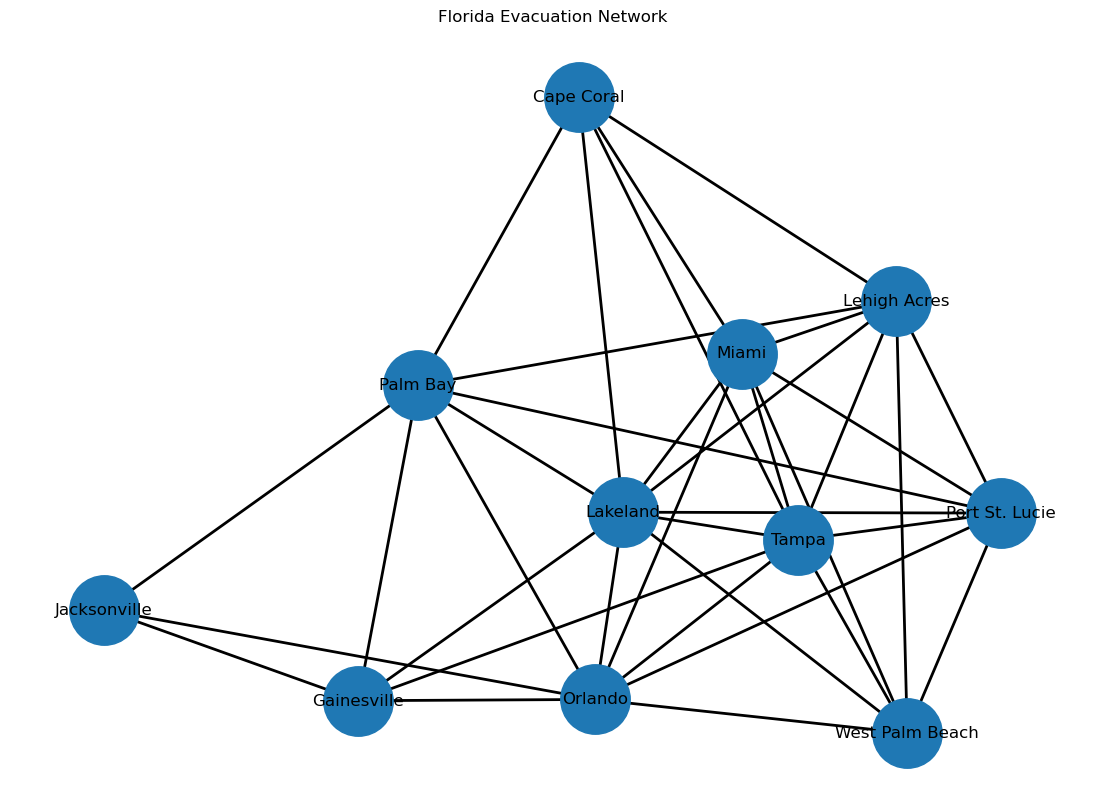

In [97]:
#network chart showing the roads (edges) and cities (nodes) for the optimization model
plt.figure(figsize=(14,10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=2500)
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edges(G, pos, width=2)

plt.title("Florida Evacuation Network")
plt.axis("off")
plt.show()

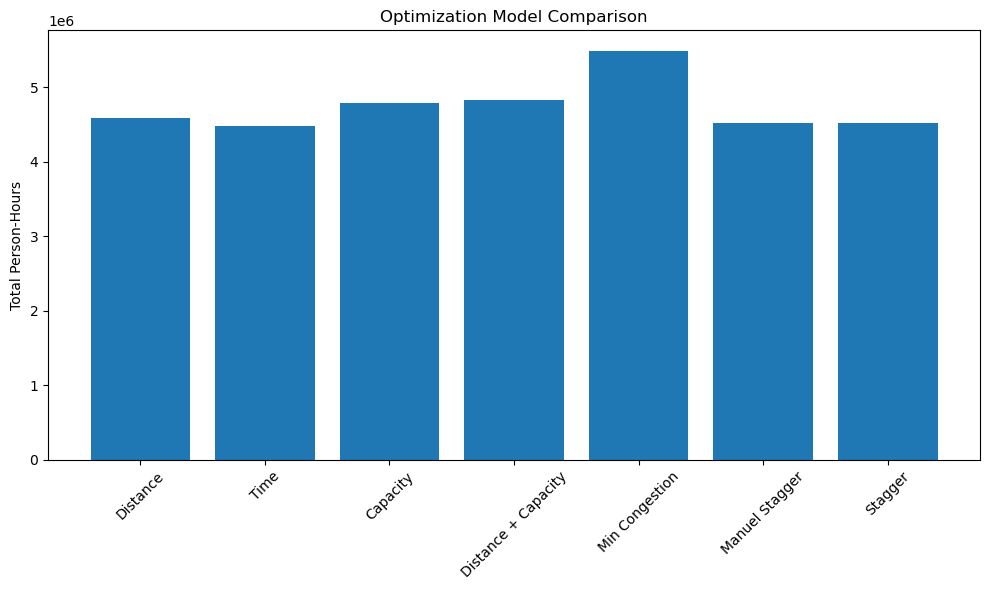

In [99]:
#bar chart for the total time to evacuate for each optimization model
plt.figure(figsize=(10,6))

plt.bar(comparison_table["Model"], comparison_table["Total Person-Hours"])

plt.ylabel("Total Person-Hours")
plt.title("Optimization Model Comparison")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

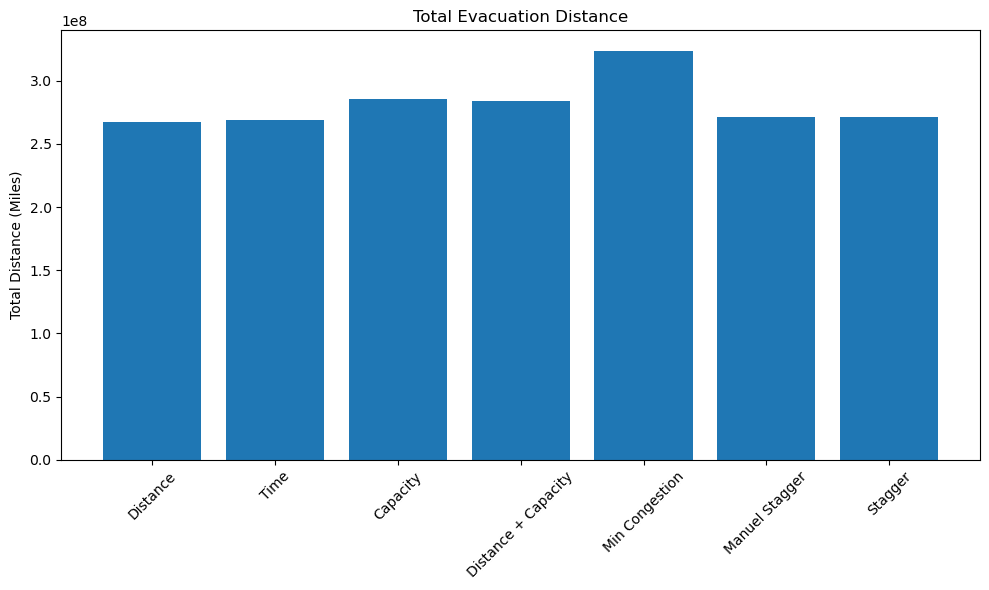

In [103]:
#bar chart for the total evacuation distance for each optimization model
plt.figure(figsize=(10,6))

plt.bar(comparison_table["Model"], comparison_table["Total Distance-Miles"])

plt.ylabel("Total Distance (Miles)")
plt.title("Total Evacuation Distance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

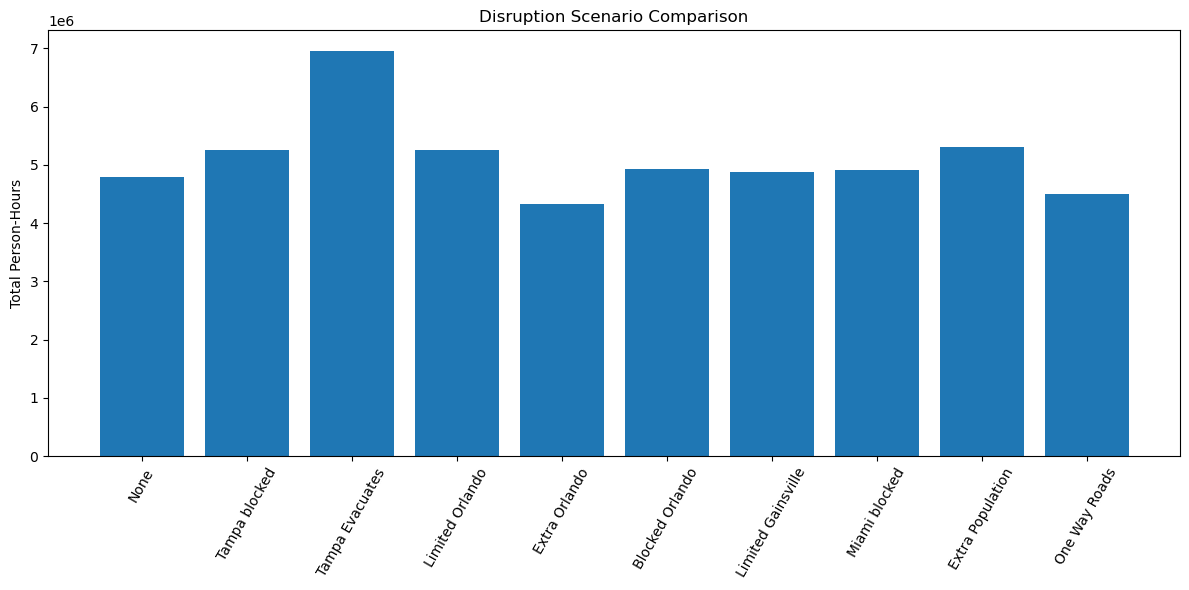

In [105]:
#bar chart showing the total time to evacuate for each disruption model
plt.figure(figsize=(12,6))

plt.bar(disruptions_table["Disruption"], disruptions_table["Total Person-Hours"])

plt.ylabel("Total Person-Hours")
plt.title("Disruption Scenario Comparison")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

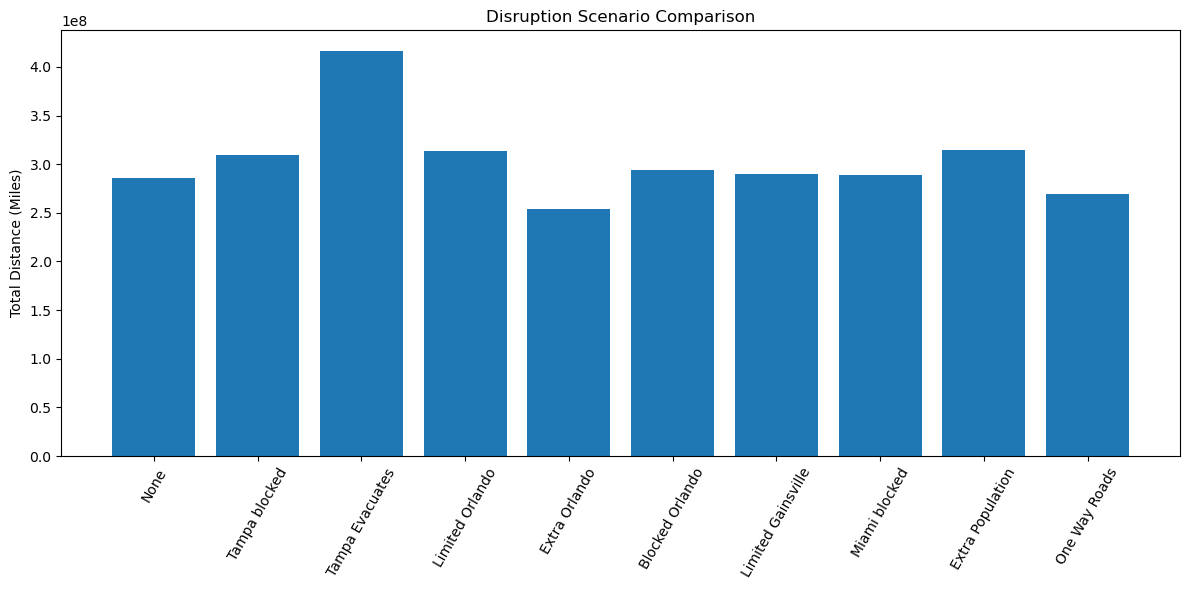

In [109]:
#bar chart showing the total distance for each disruption model
plt.figure(figsize=(12,6))

plt.bar(disruptions_table["Disruption"], disruptions_table["Total Distance-Miles"])

plt.ylabel("Total Distance (Miles)")
plt.title("Disruption Scenario Comparison")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

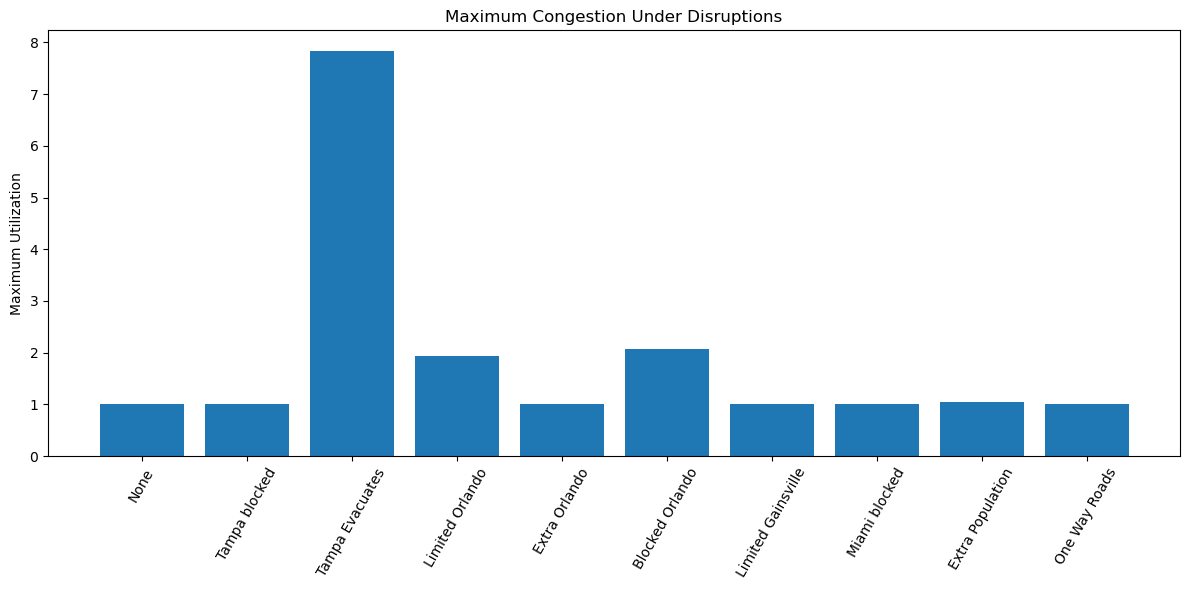

In [97]:
#bar chart showing the maximum congestion for each disruption model
plt.figure(figsize=(12,6))

plt.bar(disruptions_table["Disruption"], disruptions_table["Max Congestion"])

plt.ylabel("Maximum Utilization")
plt.title("Maximum Congestion Under Disruptions")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

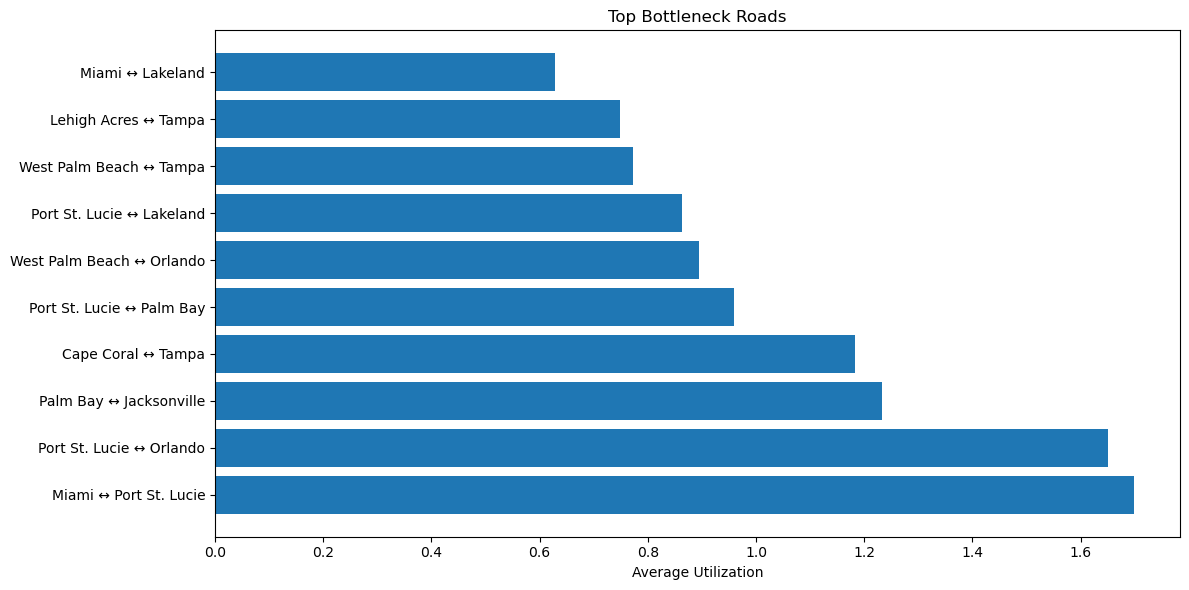

In [98]:
#bar chart showing the 10 busiest roads on average
top_roads = road_stats.sort_values("Average Utilization", ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.barh(top_roads["Road"], top_roads["Average Utilization"])

plt.xlabel("Average Utilization")
plt.title("Top Bottleneck Roads")

plt.tight_layout()
plt.show()

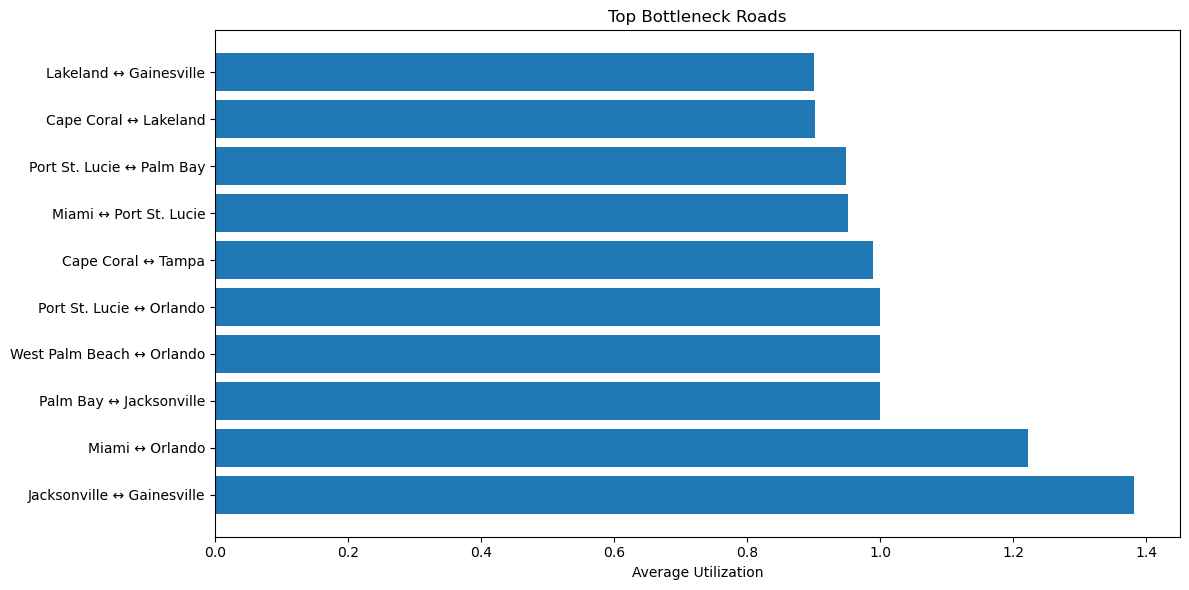

In [145]:
#bar chart showing the 10 busiest roads on average
disruption_top_roads = disruption_road_stats.sort_values("Average Utilization", ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.barh(disruption_top_roads["Road"], disruption_top_roads["Average Utilization"])

plt.xlabel("Average Utilization")
plt.title("Top Bottleneck Roads")

plt.tight_layout()
plt.show()

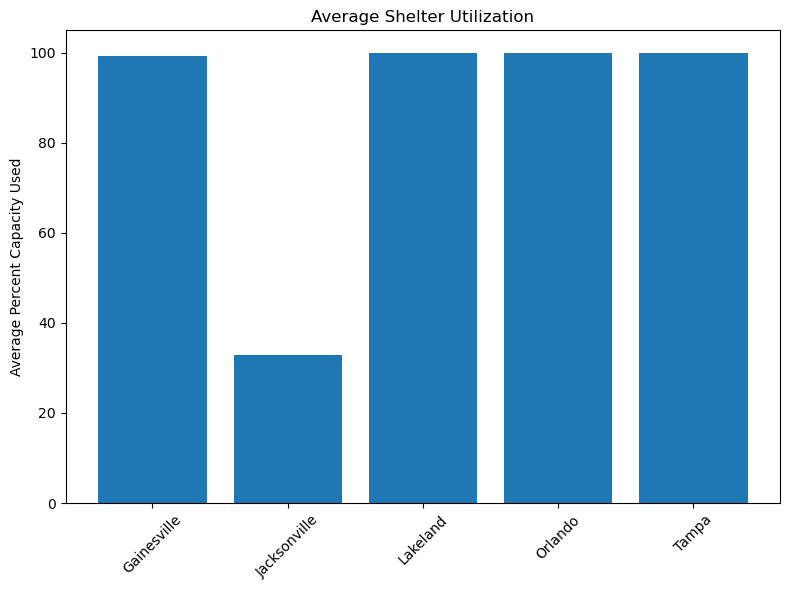

In [99]:
#bar chart showing the average shelter use of each optimization model
shelter_summary = (all_shelter_usage.groupby("Shelter")["Percent Used"].mean().reset_index())

plt.figure(figsize=(8,6))

plt.bar(shelter_summary["Shelter"], shelter_summary["Percent Used"])

plt.ylabel("Average Percent Capacity Used")
plt.title("Average Shelter Utilization")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

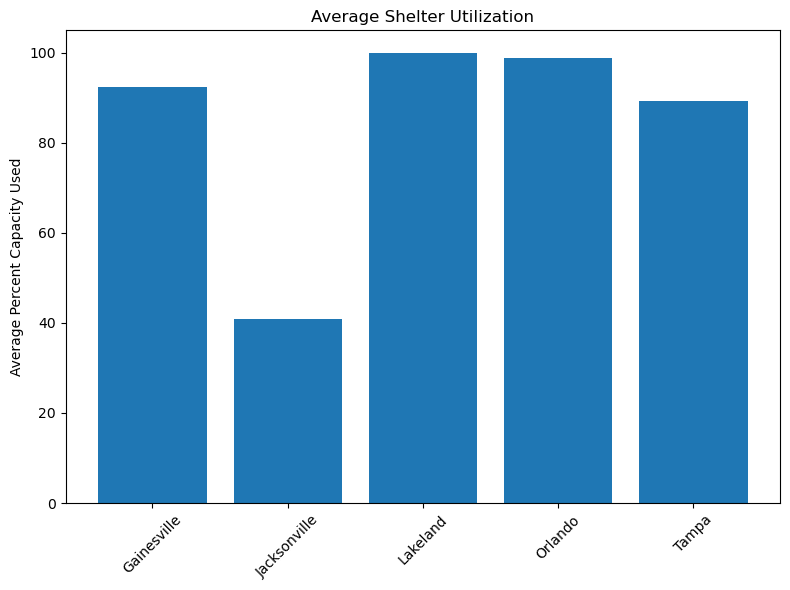

In [135]:
#bar chart showing the average shelter use of each disruption model
disruption_shelter_summary = (disruption_shelter_usage.groupby("Shelter")["Percent Used"].mean().reset_index())

plt.figure(figsize=(8,6))
plt.bar(disruption_shelter_summary["Shelter"], disruption_shelter_summary["Percent Used"])

plt.ylabel("Average Percent Capacity Used")
plt.title("Average Shelter Utilization")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

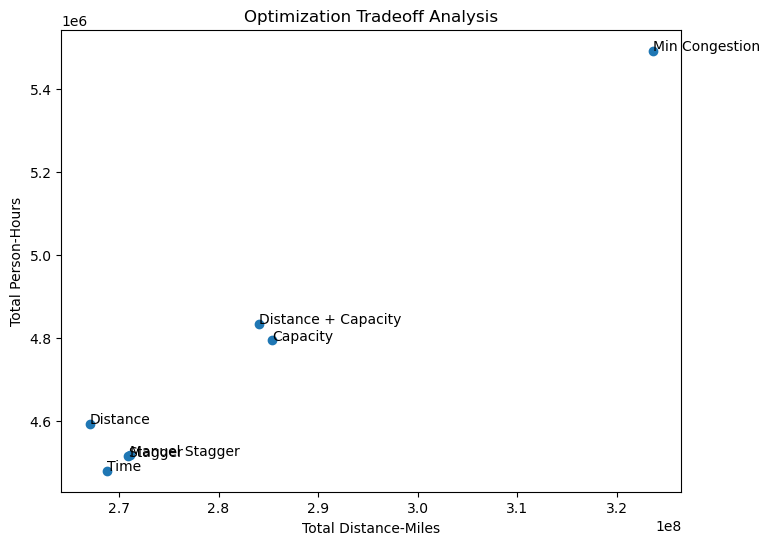

In [165]:
#scatter plot showing the tradeoff between total person hours and average distance for each optimization model
plt.figure(figsize=(8,6))

plt.scatter(comparison_table["Total Distance-Miles"], comparison_table["Total Person-Hours"])

for _, row in comparison_table.iterrows():
    plt.annotate(row["Model"], (row["Total Distance-Miles"], row["Total Person-Hours"]))

plt.xlabel("Total Distance-Miles")
plt.ylabel("Total Person-Hours")
plt.title("Optimization Tradeoff Analysis")

plt.show()

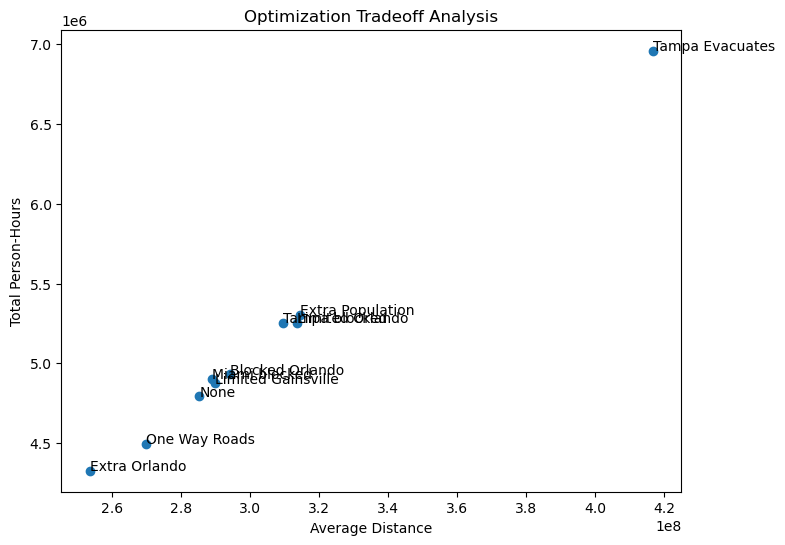

In [147]:
#scatter plot showing the tradeoff between total person hours and average distance for each disruption model
plt.figure(figsize=(8,6))

plt.scatter(disruptions_table["Total Distance-Miles"], disruptions_table["Total Person-Hours"])

for _, row in disruptions_table.iterrows():
    plt.annotate(row["Disruption"], (row["Total Distance-Miles"], row["Total Person-Hours"]))

plt.xlabel("Total Distance-Miles")
plt.ylabel("Total Person-Hours")
plt.title("Optimization Tradeoff Analysis")

plt.show()

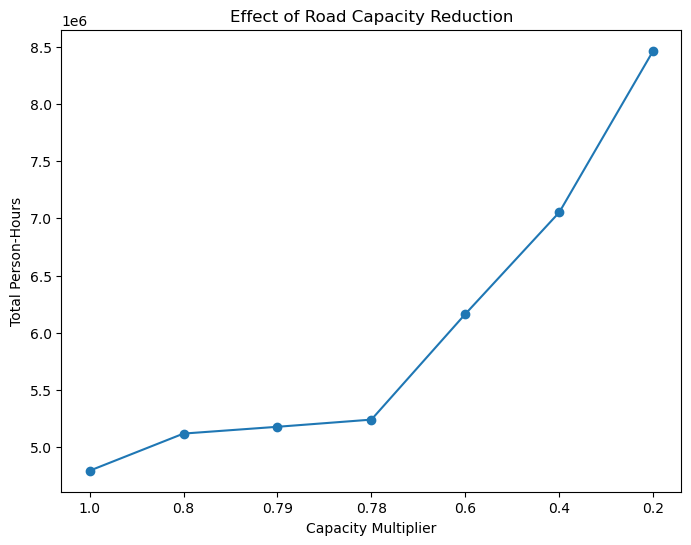

In [117]:
#chart for each capacity multiplier versus it's total person-hours
plt.figure(figsize=(8,6))

plt.plot(capacity_table["Multiplier"], capacity_table["Total Person-Hours"], marker="o")

plt.title("Effect of Road Capacity Reduction")
plt.xlabel("Capacity Multiplier")
plt.ylabel("Total Person-Hours")

plt.show()